In [1]:
# WeatherAPI.com quick notebook test (Current + 7-day forecast)
# Riviera CC ZIP: 90272

import requests
from urllib.parse import urljoin
from pprint import pprint
from src.config import get_secret

BASE_URL = "http://api.weatherapi.com/v1/"
API_KEY = get_secret("WEATHER_API_KEY")

class WeatherAPIError(RuntimeError):
    pass

def weatherapi_get(endpoint: str, *, api_key: str, q: str, **params) -> dict:
    url = urljoin(BASE_URL, endpoint.lstrip("/"))
    full_params = {"key": api_key, "q": q, **params}

    r = requests.get(url, params=full_params, timeout=20)
    try:
        data = r.json()
    except Exception as e:
        raise WeatherAPIError(f"Non-JSON response (status={r.status_code}): {r.text[:300]}") from e

    if r.status_code != 200:
        msg = data.get("error", {}).get("message") or str(data)
        raise WeatherAPIError(f"WeatherAPI error (status={r.status_code}): {msg}")

    return data

def get_current(api_key: str, q: str, *, aqi: bool = False, lang: str | None = None) -> dict:
    params = {"aqi": "yes" if aqi else "no"}
    if lang:
        params["lang"] = lang
    return weatherapi_get("current.json", api_key=api_key, q=q, **params)

def get_forecast(
    api_key: str,
    q: str,
    *,
    days: int = 7,
    aqi: bool = False,
    alerts: bool = False,
    lang: str | None = None,
) -> dict:
    if not (1 <= days <= 14):
        raise ValueError("days must be between 1 and 14")

    params = {
        "days": days,
        "aqi": "yes" if aqi else "no",
        "alerts": "yes" if alerts else "no",
    }
    if lang:
        params["lang"] = lang
    return weatherapi_get("forecast.json", api_key=api_key, q=q, **params)

def summarize_forecast(fx: dict) -> dict:
    loc = fx["location"]
    cur = fx.get("current", {})
    out = {
        "place": f'{loc.get("name")}, {loc.get("region")} ({loc.get("country")})',
        "localtime": loc.get("localtime"),
        "current": {
            "temp_f": cur.get("temp_f"),
            "feelslike_f": cur.get("feelslike_f"),
            "wind_mph": cur.get("wind_mph"),
            "wind_dir": cur.get("wind_dir"),
            "humidity": cur.get("humidity"),
            "condition": (cur.get("condition") or {}).get("text"),
        },
        "daily": [],
    }
    for d in fx["forecast"]["forecastday"]:
        day = d["day"]
        out["daily"].append({
            "date": d["date"],
            "max_f": day.get("maxtemp_f"),
            "min_f": day.get("mintemp_f"),
            "wind_mph": day.get("maxwind_mph"),
            "rain_in": day.get("totalprecip_in"),
            "chance_rain": day.get("daily_chance_of_rain"),
            "condition": (day.get("condition") or {}).get("text"),
        })
    return out

# ---- set your key here ----

# Riviera CC ZIP
Q = "90272"

# Current
cur = get_current(API_KEY, Q, aqi=False)
print("Current:", cur["location"]["name"], cur["current"]["temp_f"], "F |", cur["current"]["condition"]["text"])

# Forecast
fx = get_forecast(API_KEY, Q, days=7, aqi=False, alerts=False)
summary = summarize_forecast(fx)

print("\nSummary:")
pprint(summary)

print("\nDaily rows only:")
pprint(summary["daily"])


Current: Pacific Palisades 53.1 F | Clear

Summary:
{'current': {'condition': 'Clear',
             'feelslike_f': 49.7,
             'humidity': 59,
             'temp_f': 53.1,
             'wind_dir': 'W',
             'wind_mph': 10.3},
 'daily': [{'chance_rain': 89,
            'condition': 'Moderate rain',
            'date': '2026-02-18',
            'max_f': 60.4,
            'min_f': 46.8,
            'rain_in': 0.31,
            'wind_mph': 29.8},
           {'chance_rain': 80,
            'condition': 'Moderate rain',
            'date': '2026-02-19',
            'max_f': 55.6,
            'min_f': 42.3,
            'rain_in': 0.54,
            'wind_mph': 17.9},
           {'chance_rain': 0,
            'condition': 'Cloudy ',
            'date': '2026-02-20',
            'max_f': 52.7,
            'min_f': 41.5,
            'rain_in': 0.0,
            'wind_mph': 8.9},
           {'chance_rain': 0,
            'condition': 'Fog',
            'date': '2026-02-21',
         

In [5]:
import requests
import pandas as pd
from urllib.parse import urljoin

BASE_URL = "http://api.weatherapi.com/v1/"

class WeatherAPIError(RuntimeError):
    pass

def _get_json(endpoint: str, params: dict, timeout: int = 20) -> dict:
    url = urljoin(BASE_URL, endpoint.lstrip("/"))
    r = requests.get(url, params=params, timeout=timeout)
    try:
        data = r.json()
    except Exception as e:
        raise WeatherAPIError(f"Non-JSON response (status={r.status_code}): {r.text[:300]}") from e
    if r.status_code != 200:
        msg = data.get("error", {}).get("message") or str(data)
        raise WeatherAPIError(f"WeatherAPI error (status={r.status_code}): {msg}")
    return data

def history_hourly_one_day(api_key: str, q: str, dt: str, *, lang: str | None = None) -> pd.DataFrame:
    """
    dt: 'YYYY-MM-DD'
    Returns 24 rows (usually) of hourly observations for that date.
    """
    params = {"key": api_key, "q": q, "dt": dt}
    if lang:
        params["lang"] = lang

    data = _get_json("history.json", params=params)

    loc = data["location"]
    day = data["forecast"]["forecastday"][0]  # history response uses forecast->forecastday
    hours = day["hour"]

    rows = []
    for h in hours:
        rows.append({
            "dt_local": h.get("time"),                 # local time string
            "date": day.get("date"),
            "tz_id": loc.get("tz_id"),
            "name": loc.get("name"),
            "region": loc.get("region"),
            "country": loc.get("country"),

            "temp_f": h.get("temp_f"),
            "feelslike_f": h.get("feelslike_f"),
            "humidity": h.get("humidity"),
            "wind_mph": h.get("wind_mph"),
            "wind_dir": h.get("wind_dir"),
            "gust_mph": h.get("gust_mph"),
            "pressure_in": h.get("pressure_in"),
            "precip_in": h.get("precip_in"),
            "cloud": h.get("cloud"),
            "vis_miles": h.get("vis_miles"),
            "uv": h.get("uv"),
            "condition": (h.get("condition") or {}).get("text"),
        })

    df = pd.DataFrame(rows)
    # Parse local timestamp
    df["dt_local"] = pd.to_datetime(df["dt_local"], errors="coerce")
    return df

def history_hourly_range(api_key: str, q: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Inclusive date range, one request per day.
    start_date/end_date: 'YYYY-MM-DD'
    """
    dates = pd.date_range(start_date, end_date, freq="D")
    dfs = []
    for d in dates:
        dt = d.strftime("%Y-%m-%d")
        dfs.append(history_hourly_one_day(api_key, q, dt))
    out = pd.concat(dfs, ignore_index=True).sort_values("dt_local")
    return out

# -------------------------
# Use it
# -------------------------
Q = "90272"  # Riviera area ZIP

df_hourly = history_hourly_range(API_KEY, Q, "2026-02-19", "2026-02-22")
df_hourly


WeatherAPIError: WeatherAPI error (status=401): API key is invalid.

In [6]:
import requests
import pandas as pd
from urllib.parse import urljoin

BASE_URL = "http://api.weatherapi.com/v1/"

class WeatherAPIError(RuntimeError):
    pass

def _get_json(endpoint: str, params: dict, timeout: int = 20) -> dict:
    url = urljoin(BASE_URL, endpoint.lstrip("/"))
    r = requests.get(url, params=params, timeout=timeout)
    try:
        data = r.json()
    except Exception as e:
        raise WeatherAPIError(f"Non-JSON response (status={r.status_code}): {r.text[:300]}") from e
    if r.status_code != 200:
        msg = data.get("error", {}).get("message") or str(data)
        raise WeatherAPIError(f"WeatherAPI error (status={r.status_code}): {msg}")
    return data

def forecast_hourly_between(api_key: str, q: str, start_date: str, end_date: str) -> pd.DataFrame:
    """
    Pull ONE forecast request (days=1..14) and return hourly rows between start_date and end_date inclusive.
    Dates: 'YYYY-MM-DD'
    """
    start = pd.to_datetime(start_date).date()
    end = pd.to_datetime(end_date).date()
    if end < start:
        raise ValueError("end_date must be >= start_date")

    # WeatherAPI forecast uses days count starting from "today"
    # We'll request enough days to cover end_date, but cap at 14.
    today = pd.Timestamp.now().date()
    days_needed = (end - today).days + 1
    if days_needed < 1:
        raise ValueError("These dates are not in the forecast window (they're in the past). Use history.json for past dates.")
    if days_needed > 14:
        raise ValueError("End date is beyond 14-day forecast window. Use future.json (plan-dependent) or another provider.")

    data = _get_json(
        "forecast.json",
        params={
            "key": api_key,
            "q": q,
            "days": int(days_needed),
            "aqi": "no",
            "alerts": "no",
        },
    )

    loc = data["location"]
    rows = []
    for fd in data["forecast"]["forecastday"]:
        d = pd.to_datetime(fd["date"]).date()
        if d < start or d > end:
            continue
        for h in fd["hour"]:
            rows.append({
                "dt_local": h.get("time"),
                "date": fd.get("date"),
                "tz_id": loc.get("tz_id"),
                "name": loc.get("name"),
                "region": loc.get("region"),
                "country": loc.get("country"),
                "lat": loc.get("lat"),
                "lon": loc.get("lon"),

                "temp_f": h.get("temp_f"),
                "feelslike_f": h.get("feelslike_f"),
                "humidity": h.get("humidity"),
                "wind_mph": h.get("wind_mph"),
                "wind_dir": h.get("wind_dir"),
                "gust_mph": h.get("gust_mph"),
                "pressure_in": h.get("pressure_in"),
                "precip_in": h.get("precip_in"),
                "chance_of_rain": h.get("chance_of_rain"),
                "cloud": h.get("cloud"),
                "vis_miles": h.get("vis_miles"),
                "uv": h.get("uv"),
                "condition": (h.get("condition") or {}).get("text"),
            })

    df = pd.DataFrame(rows)
    df["dt_local"] = pd.to_datetime(df["dt_local"], errors="coerce")
    df = df.sort_values("dt_local").reset_index(drop=True)
    return df

# ---- run it ----
API_KEY = "37a2c5c67db34e6e970210615261702"
Q = "90272"

df_hourly = forecast_hourly_between(API_KEY, Q, "2026-02-19", "2026-02-22")
df_hourly


,dt_local,date,tz_id,name,region,country,lat,lon,temp_f,feelslike_f,...,wind_mph,wind_dir,gust_mph,pressure_in,precip_in,chance_of_rain,cloud,vis_miles,uv,condition
0,2026-02-19 00:00:00,2026-02-19,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,47.3,46.0,...,5.1,NW,7.1,30.05,0.0,0,35,6.0,0.0,Partly Cloudy
1,2026-02-19 01:00:00,2026-02-19,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,46.1,44.7,...,5.1,NW,7.3,30.06,0.0,0,43,6.0,0.0,Partly Cloudy
2,2026-02-19 02:00:00,2026-02-19,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,45.1,43.5,...,5.1,NW,7.4,30.06,0.0,0,51,6.0,0.0,Partly Cloudy
3,2026-02-19 03:00:00,2026-02-19,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,44.3,42.7,...,5.1,NW,7.4,30.05,0.0,0,57,6.0,0.0,Partly Cloudy
4,2026-02-19 04:00:00,2026-02-19,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,43.6,42.0,...,4.7,WNW,6.8,30.05,0.0,0,60,6.0,0.0,Partly Cloudy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,2026-02-22 19:00:00,2026-02-22,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,61.4,61.4,...,4.9,W,7.1,30.21,0.0,0,43,6.0,0.0,Partly Cloudy
92,2026-02-22 20:00:00,2026-02-22,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,61.1,61.1,...,4.3,W,6.3,30.22,0.0,0,47,6.0,0.0,Partly Cloudy
93,2026-02-22 21:00:00,2026-02-22,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,60.9,60.9,...,3.8,W,5.6,30.22,0.0,0,52,6.0,0.0,Partly Cloudy
94,2026-02-22 22:00:00,2026-02-22,America/Los_Angeles,Pacific Palisades,California,USA,34.0481,-118.526001,60.7,60.7,...,3.1,W,4.9,30.23,0.0,0,56,6.0,0.0,Partly Cloudy


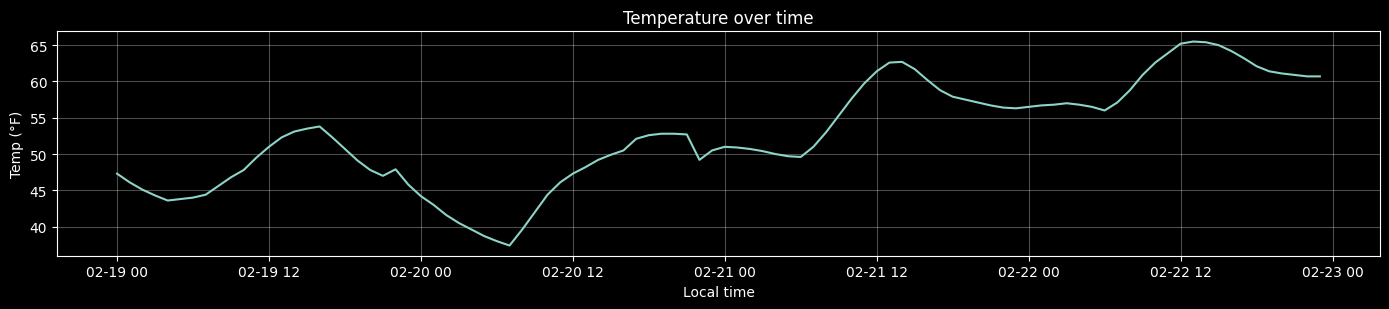

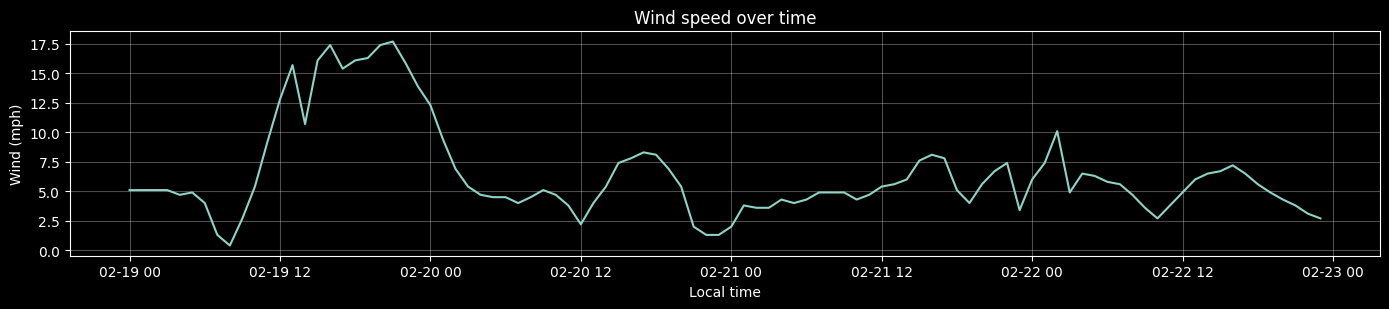

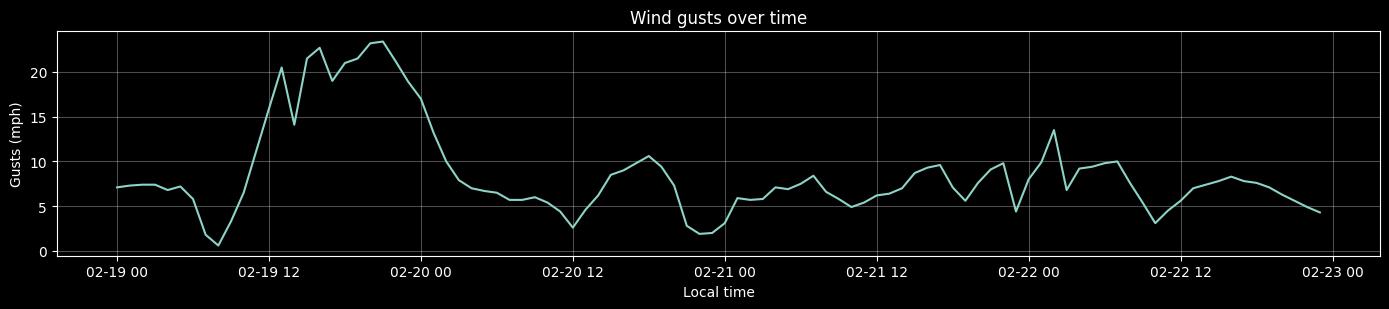

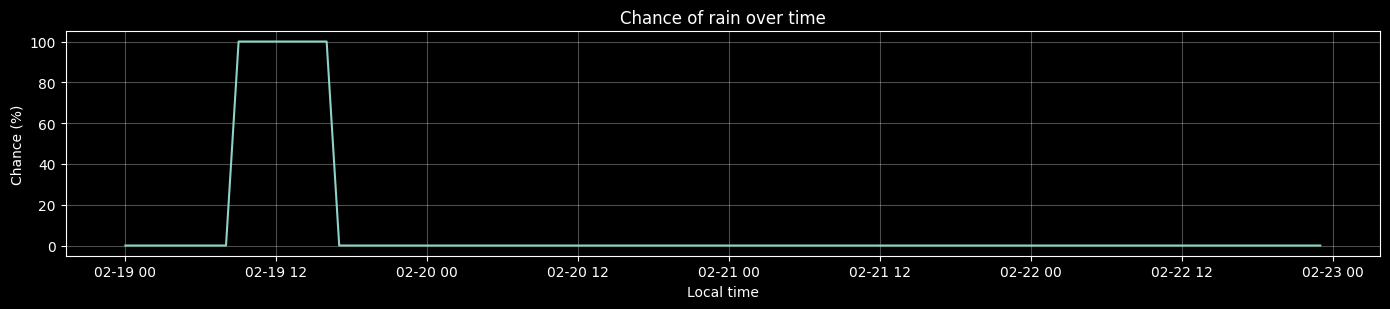

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# If your dataframe has a different name, change df_hourly below.
dfp = df_hourly.copy()

# Clean + sort
dfp["dt_local"] = pd.to_datetime(dfp["dt_local"], errors="coerce")
dfp = dfp.dropna(subset=["dt_local"]).sort_values("dt_local")

# Force numeric (WeatherAPI sometimes returns strings)
for c in ["temp_f", "wind_mph", "gust_mph", "chance_of_rain"]:
    if c in dfp.columns:
        dfp[c] = pd.to_numeric(dfp[c], errors="coerce")

def line_chart(ycol: str, ylabel: str, title: str):
    if ycol not in dfp.columns:
        raise KeyError(f"Column '{ycol}' not found. Available: {list(dfp.columns)}")

    fig, ax = plt.subplots(figsize=(14, 3.2))
    ax.plot(dfp["dt_local"], dfp[ycol])
    ax.set_title(title)
    ax.set_xlabel("Local time")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

line_chart("temp_f", "Temp (°F)", "Temperature over time")
line_chart("wind_mph", "Wind (mph)", "Wind speed over time")
line_chart("gust_mph", "Gusts (mph)", "Wind gusts over time")
line_chart("chance_of_rain", "Chance (%)", "Chance of rain over time")


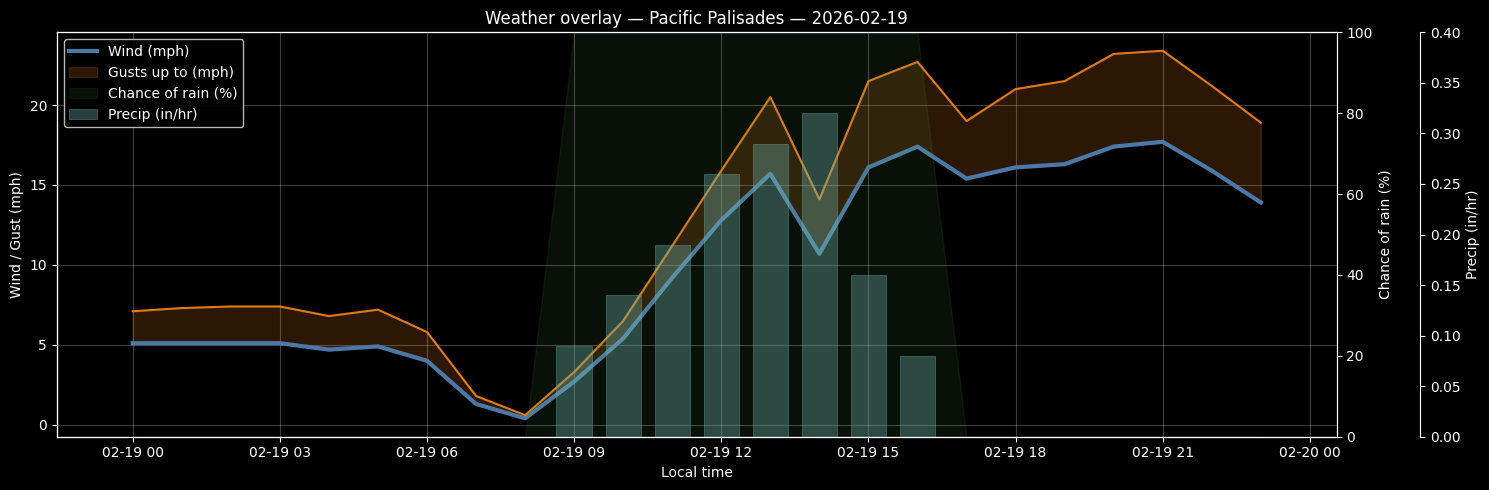

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_day_wind_rain_precip(dfp: pd.DataFrame, day: str):
    d = dfp.copy()
    d["dt_local"] = pd.to_datetime(d["dt_local"], errors="coerce")
    d = d.dropna(subset=["dt_local"]).sort_values("dt_local")

    day_date = pd.to_datetime(day).date()
    d = d[d["dt_local"].dt.date == day_date].copy()
    if d.empty:
        raise ValueError(f"No data for {day}. Available days: {sorted(dfp['dt_local'].dt.date.unique())}")

    # Ensure numeric
    needed = ["wind_mph", "gust_mph", "chance_of_rain", "precip_in"]
    for c in needed:
        if c not in d.columns:
            raise KeyError(f"Missing column '{c}'. Available: {list(d.columns)}")
        d[c] = pd.to_numeric(d[c], errors="coerce")

    x = d["dt_local"]
    wind = d["wind_mph"]
    gust = d["gust_mph"]
    rain = d["chance_of_rain"].clip(lower=0, upper=100)
    precip = d["precip_in"].clip(lower=0)

    # High-contrast palette
    c_wind = "#4C78A8"   # blue
    c_gust = "#F58518"   # orange
    c_rain = "#54A24B"   # green
    c_prec = "#72B7B2"   # teal

    fig, ax_wind = plt.subplots(figsize=(15, 5))

    # --- WIND (hero line) ---
    ax_wind.plot(x, wind, color=c_wind, linewidth=3.0, label="Wind (mph)", zorder=5)

    # --- GUST band (wind -> gust) + outline for readability ---
    ax_wind.fill_between(
        x, wind, gust,
        where=(gust >= wind),
        interpolate=True,
        color=c_gust,
        alpha=0.18,
        label="Gusts up to (mph)",
        zorder=4,
    )
    # Outline the gust top so the band edge is visible
    ax_wind.plot(x, gust, color=c_gust, linewidth=1.5, alpha=0.9, zorder=6)

    ax_wind.set_ylabel("Wind / Gust (mph)")
    ax_wind.set_xlabel("Local time")
    ax_wind.grid(True, alpha=0.25, zorder=0)

    # --- Chance of rain (%) as light area on right axis ---
    ax_rain = ax_wind.twinx()
    ax_rain.fill_between(
        x, 0, rain,
        color=c_rain,
        alpha=0.10,           # keep it subtle so it doesn't muddy the plot
        label="Chance of rain (%)",
        zorder=1,
    )
    ax_rain.set_ylim(0, 100)
    ax_rain.set_ylabel("Chance of rain (%)")

    # --- Precip (in/hr) as bars on a second right axis (offset outward) ---
    ax_prec = ax_wind.twinx()
    ax_prec.spines["right"].set_position(("outward", 60))

    # Width tuned for hourly timestamps (matplotlib uses days as units)
    bar_width = 0.03
    ax_prec.bar(
        x, precip,
        width=bar_width,
        color=c_prec,
        alpha=0.35,
        edgecolor=c_prec,
        linewidth=0.7,
        label="Precip (in/hr)",
        zorder=2,
    )

    # Set a sensible precip axis max so tiny bars are still visible
    pmax = float(precip.max()) if precip.notna().any() else 0.0
    ax_prec.set_ylim(0, max(0.05, pmax * 1.25))
    ax_prec.set_ylabel("Precip (in/hr)")

    # Title
    title_loc = ""
    if "name" in d.columns and d["name"].notna().any():
        title_loc = f" — {d['name'].dropna().iloc[0]}"
    ax_wind.set_title(f"Weather overlay{title_loc} — {day}")

    # Combined legend
    handles, labels = [], []
    for ax in (ax_wind, ax_rain, ax_prec):
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    ax_wind.legend(handles, labels, loc="upper left", framealpha=0.9)

    plt.tight_layout()
    plt.show()

# Example:
plot_day_wind_rain_precip(dfp, "2026-02-19")


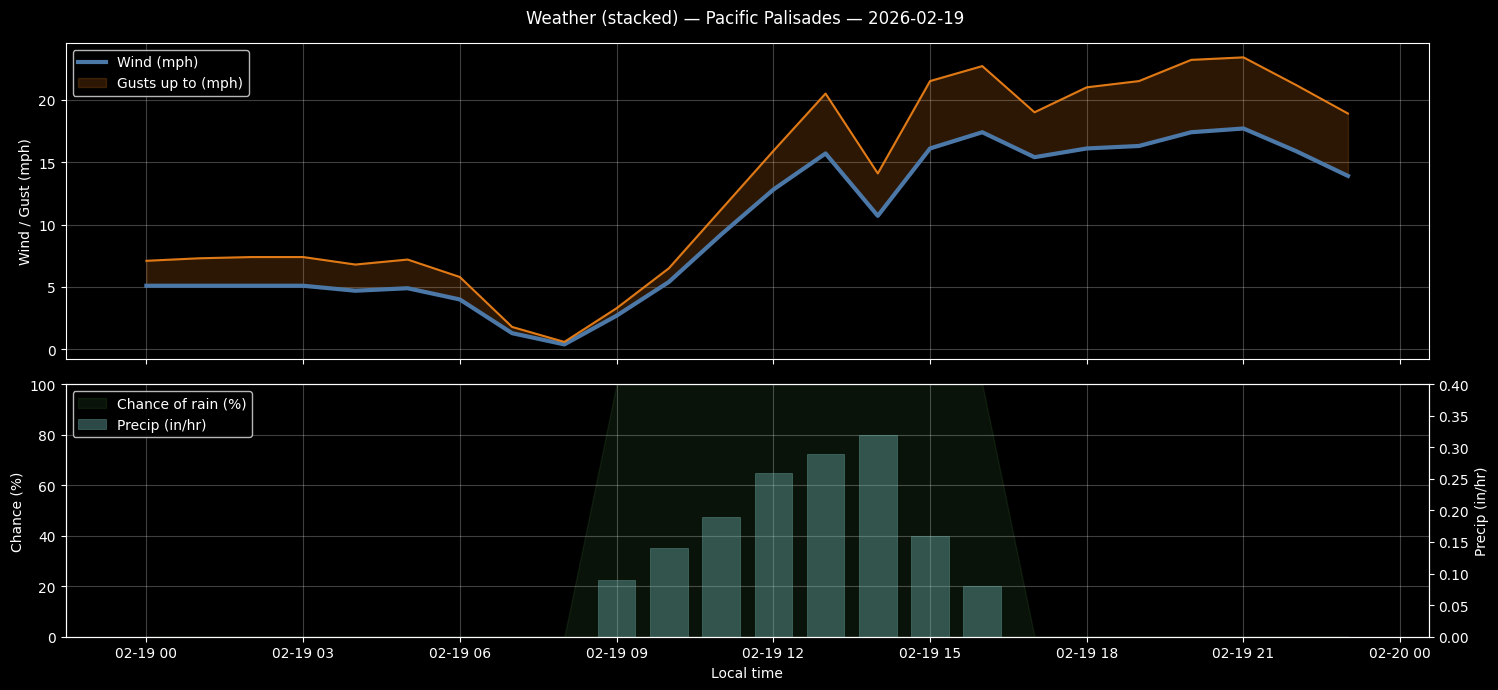

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_day_two_panel(
    dfp: pd.DataFrame,
    day: str,
    *,
    tee_times=None,          # list of datetimes or strings; optional
    tee_labels=None,         # list[str] same length as tee_times; optional
    waves=None,              # list of (start, end, label) as datetimes/strings; optional
    show_legend=True
):
    """
    Two stacked charts sharing x:
      (1) Wind + gust band
      (2) Chance of rain area + precip bars

    tee_times: list of timestamps (or 'YYYY-MM-DD HH:MM') for vertical lines
    waves: list of (start, end, label) for shaded blocks
    """

    d = dfp.copy()
    d["dt_local"] = pd.to_datetime(d["dt_local"], errors="coerce")
    d = d.dropna(subset=["dt_local"]).sort_values("dt_local")

    day_date = pd.to_datetime(day).date()
    d = d[d["dt_local"].dt.date == day_date].copy()
    if d.empty:
        raise ValueError(f"No data for {day}. Available days: {sorted(dfp['dt_local'].dt.date.unique())}")

    # numeric columns
    for c in ["wind_mph", "gust_mph", "chance_of_rain", "precip_in"]:
        if c not in d.columns:
            raise KeyError(f"Missing '{c}' in df. Available: {list(d.columns)}")
        d[c] = pd.to_numeric(d[c], errors="coerce")

    x = d["dt_local"]
    wind = d["wind_mph"]
    gust = d["gust_mph"]
    rain = d["chance_of_rain"].clip(0, 100)
    precip = d["precip_in"].clip(lower=0)

    # Parse tee times / waves
    if tee_times is not None:
        tee_times = [pd.to_datetime(t) for t in tee_times]
        if tee_labels is None:
            tee_labels = [None] * len(tee_times)
        if len(tee_labels) != len(tee_times):
            raise ValueError("tee_labels must be same length as tee_times")

    if waves is not None:
        parsed_waves = []
        for w in waves:
            if len(w) != 3:
                raise ValueError("Each wave must be (start, end, label)")
            s, e, lab = w
            parsed_waves.append((pd.to_datetime(s), pd.to_datetime(e), lab))
        waves = parsed_waves

    # Colors
    c_wind = "#4C78A8"  # blue
    c_gust = "#F58518"  # orange
    c_rain = "#54A24B"  # green
    c_prec = "#72B7B2"  # teal

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 7), sharex=True,
        gridspec_kw={"height_ratios": [2, 1.6]}
    )

    # -------------------
    # Panel 1: Wind/Gusts
    # -------------------
    ax1.plot(x, wind, color=c_wind, linewidth=3.0, label="Wind (mph)", zorder=5)
    ax1.fill_between(
        x, wind, gust,
        where=(gust >= wind),
        interpolate=True,
        color=c_gust, alpha=0.18,
        label="Gusts up to (mph)",
        zorder=4
    )
    ax1.plot(x, gust, color=c_gust, linewidth=1.5, alpha=0.9, zorder=6)
    ax1.set_ylabel("Wind / Gust (mph)")
    ax1.grid(True, alpha=0.25)

    # -------------------------
    # Panel 2: Rain + Precip
    # -------------------------
    # Rain area (%)
    ax2.fill_between(
        x, 0, rain,
        color=c_rain, alpha=0.12,
        label="Chance of rain (%)",
        zorder=1
    )
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("Chance (%)")
    ax2.grid(True, alpha=0.25)

    # Precip bars on twin axis (so inches/hr scale is readable)
    ax2p = ax2.twinx()
    bar_width = 0.03  # hourly timestamps
    ax2p.bar(
        x, precip,
        width=bar_width,
        color=c_prec, alpha=0.40,
        edgecolor=c_prec, linewidth=0.6,
        label="Precip (in/hr)",
        zorder=2
    )
    pmax = float(precip.max()) if precip.notna().any() else 0.0
    ax2p.set_ylim(0, max(0.05, pmax * 1.25))
    ax2p.set_ylabel("Precip (in/hr)")

    # -------------------------
    # Tee times / waves overlay
    # -------------------------
    def _overlay_on(ax):
        # waves as shaded blocks (best for AM/PM comparisons)
        if waves is not None:
            for s, e, lab in waves:
                ax.axvspan(s, e, alpha=0.08, zorder=0)
                if lab:
                    ax.text(
                        s + (e - s) / 50,  # small inset from left edge
                        ax.get_ylim()[1] * 0.95,
                        lab,
                        va="top",
                        fontsize=10
                    )
        # tee times as vertical lines
        if tee_times is not None:
            for t, lab in zip(tee_times, tee_labels):
                ax.axvline(t, linewidth=1.2, alpha=0.6, zorder=10)
                if lab:
                    ax.text(t, ax.get_ylim()[1] * 0.9, lab, rotation=90, va="top", ha="right", fontsize=9)

    _overlay_on(ax1)
    _overlay_on(ax2)

    # Title
    title_loc = ""
    if "name" in d.columns and d["name"].notna().any():
        title_loc = f" — {d['name'].dropna().iloc[0]}"
    fig.suptitle(f"Weather (stacked){title_loc} — {day}", y=0.98)

    ax2.set_xlabel("Local time")

    # Legends
    if show_legend:
        ax1.legend(loc="upper left", framealpha=0.9)
        # combined legend for panel 2 (ax2 + ax2p)
        h2, l2 = ax2.get_legend_handles_labels()
        h2p, l2p = ax2p.get_legend_handles_labels()
        ax2.legend(h2 + h2p, l2 + l2p, loc="upper left", framealpha=0.9)

    plt.tight_layout()
    plt.show()

# Example:
plot_day_two_panel(dfp, "2026-02-19")


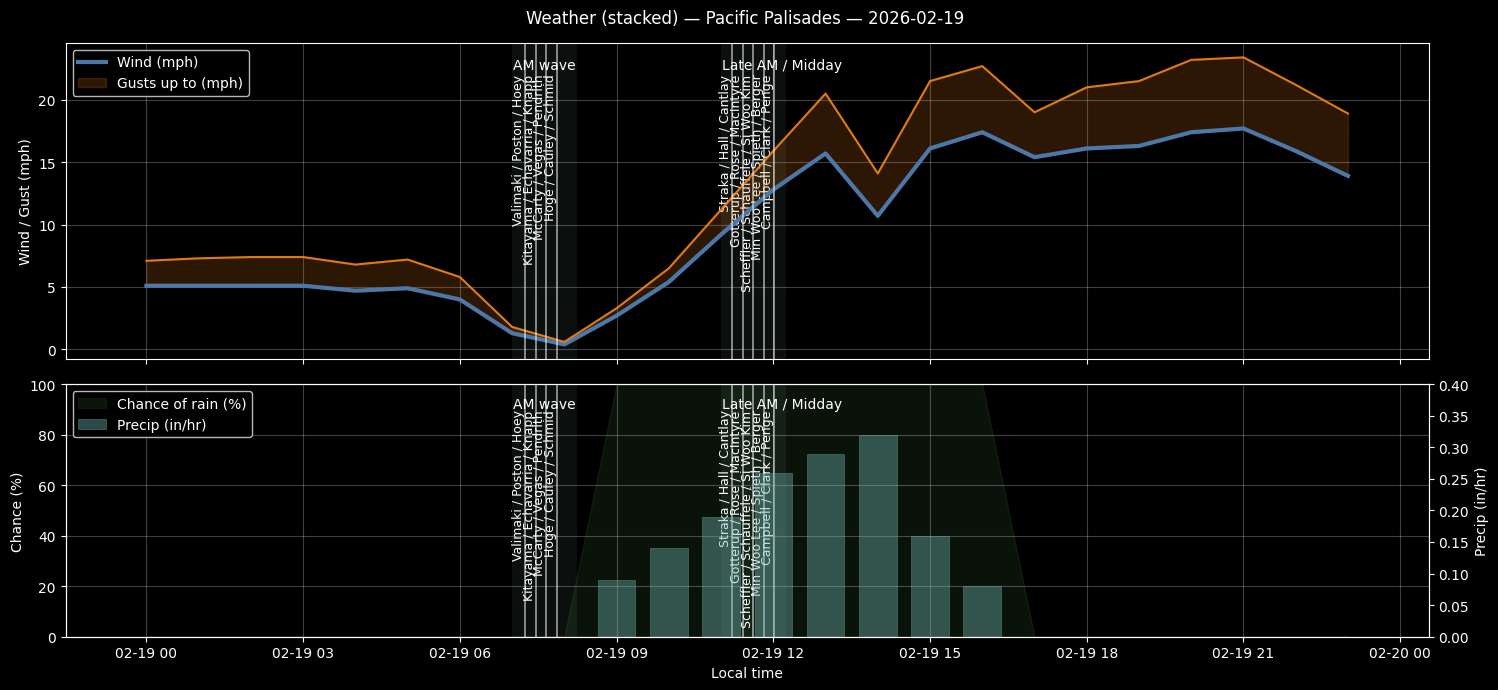

In [19]:
# Hardcoded tee times example (given in EST -> converted to PST by subtracting 3 hours)
# Use these with plot_day_two_panel(...) from earlier

# -------------------------
# Tee times (PST) + labels
# -------------------------
tee_times = [
    "2026-02-19 07:15",  # 10:15 AM EST
    "2026-02-19 07:27",  # 10:27 AM EST
    "2026-02-19 07:39",  # 10:39 AM EST
    "2026-02-19 07:51",  # 10:51 AM EST
    "2026-02-19 11:13",  # 2:13 PM EST
    "2026-02-19 11:25",  # 2:25 PM EST
    "2026-02-19 11:37",  # 2:37 PM EST
    "2026-02-19 11:49",  # 2:49 PM EST
    "2026-02-19 12:01",  # 3:01 PM EST
]

tee_labels = [
    "Valimaki / Poston / Hoey",
    "Kitayama / Echavarria / Knapp",
    "McCarty / Vegas / Pendrith",
    "Hoge / Cauley / Schmid",
    "Straka / Hall / Cantlay",
    "Gotterup / Rose / MacIntyre",
    "Scheffler / Schauffele / Si Woo Kim",
    "Min Woo Lee / Spieth / Berger",
    "Campbell / Clark / Penge",
]

# Optional: shaded wave blocks (PST) for readability
waves = [
    ("2026-02-19 07:00", "2026-02-19 08:15", "AM wave"),
    ("2026-02-19 11:00", "2026-02-19 12:15", "Late AM / Midday"),
]

# -------------------------
# Call your stacked plot
# -------------------------
plot_day_two_panel(
    dfp,
    "2026-02-19",
    tee_times=tee_times,
    tee_labels=tee_labels,
    waves=waves,
)


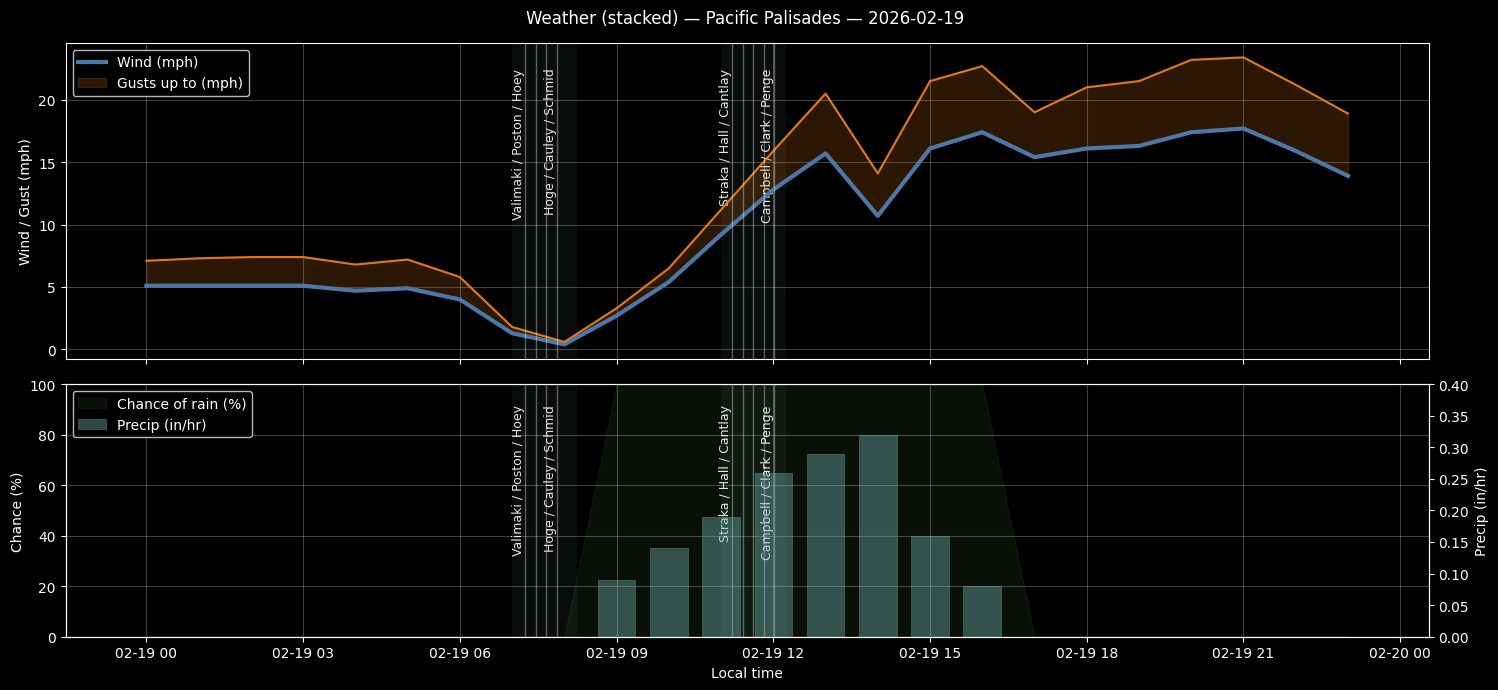

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_day_two_panel_clean(
    dfp: pd.DataFrame,
    day: str,
    *,
    tee_times=None,
    tee_labels=None,
    waves=None,                 # keep for shading only (no labels)
    label_strategy="cluster_ends",  # "none" | "first_last" | "cluster_ends"
    cluster_gap_minutes=25,     # used for "cluster_ends"
):
    d = dfp.copy()
    d["dt_local"] = pd.to_datetime(d["dt_local"], errors="coerce")
    d = d.dropna(subset=["dt_local"]).sort_values("dt_local")

    day_date = pd.to_datetime(day).date()
    d = d[d["dt_local"].dt.date == day_date].copy()
    if d.empty:
        raise ValueError(f"No data for {day}. Available days: {sorted(dfp['dt_local'].dt.date.unique())}")

    for c in ["wind_mph", "gust_mph", "chance_of_rain", "precip_in"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    x = d["dt_local"]
    wind = d["wind_mph"]
    gust = d["gust_mph"]
    rain = d["chance_of_rain"].clip(0, 100)
    precip = d["precip_in"].clip(lower=0)

    # Parse tees
    if tee_times is not None:
        tee_times = [pd.to_datetime(t) for t in tee_times]
        if tee_labels is None:
            tee_labels = [None] * len(tee_times)
        if len(tee_labels) != len(tee_times):
            raise ValueError("tee_labels must match tee_times length")

    # Parse waves (shading only)
    if waves is not None:
        waves = [(pd.to_datetime(s), pd.to_datetime(e)) for (s, e, *_rest) in waves]  # ignore label if provided

    # Colors
    c_wind = "#4C78A8"
    c_gust = "#F58518"
    c_rain = "#54A24B"
    c_prec = "#72B7B2"

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 7), sharex=True,
        gridspec_kw={"height_ratios": [2, 1.6]}
    )

    # ---- Panel 1: Wind/Gust ----
    ax1.plot(x, wind, color=c_wind, linewidth=3.0, label="Wind (mph)", zorder=5)
    ax1.fill_between(x, wind, gust, where=(gust >= wind), interpolate=True,
                     color=c_gust, alpha=0.18, label="Gusts up to (mph)", zorder=4)
    ax1.plot(x, gust, color=c_gust, linewidth=1.5, alpha=0.9, zorder=6)
    ax1.set_ylabel("Wind / Gust (mph)")
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="upper left", framealpha=0.9)

    # ---- Panel 2: Rain + Precip ----
    ax2.fill_between(x, 0, rain, color=c_rain, alpha=0.10, label="Chance of rain (%)", zorder=1)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("Chance (%)")
    ax2.grid(True, alpha=0.25)

    ax2p = ax2.twinx()
    ax2p.bar(x, precip, width=0.03, color=c_prec, alpha=0.40,
             edgecolor=c_prec, linewidth=0.6, label="Precip (in/hr)", zorder=2)
    pmax = float(precip.max()) if precip.notna().any() else 0.0
    ax2p.set_ylim(0, max(0.05, pmax * 1.25))
    ax2p.set_ylabel("Precip (in/hr)")

    h2, l2 = ax2.get_legend_handles_labels()
    h2p, l2p = ax2p.get_legend_handles_labels()
    ax2.legend(h2 + h2p, l2 + l2p, loc="upper left", framealpha=0.9)

    # ---- Optional wave shading (no labels) ----
    if waves is not None:
        for s, e in waves:
            ax1.axvspan(s, e, alpha=0.06, zorder=0)
            ax2.axvspan(s, e, alpha=0.06, zorder=0)

    # ---- Tee lines (clean) ----
    def overlay_tees(ax):
        if tee_times is None:
            return

        # draw all lines, lightly
        for t in tee_times:
            ax.axvline(t, linewidth=1.0, alpha=0.35, zorder=10)

        if label_strategy == "none":
            return

        # pick indices to label
        idx_to_label = set()
        if label_strategy == "first_last":
            idx_to_label.update({0, len(tee_times) - 1})

        elif label_strategy == "cluster_ends":
            # cluster tee times by gaps
            gap = pd.Timedelta(minutes=cluster_gap_minutes)
            times_sorted = sorted((t, i) for i, t in enumerate(tee_times))
            clusters = [[times_sorted[0]]]
            for item in times_sorted[1:]:
                if item[0] - clusters[-1][-1][0] <= gap:
                    clusters[-1].append(item)
                else:
                    clusters.append([item])
            # label first & last of each cluster
            for cl in clusters:
                idx_to_label.add(cl[0][1])
                idx_to_label.add(cl[-1][1])

        # place labels near the top, minimal
        y = ax.get_ylim()[1] * 0.92
        for i in sorted(idx_to_label):
            t = tee_times[i]
            lab = tee_labels[i] if tee_labels else None
            if not lab:
                continue
            ax.text(t, y, lab, rotation=90, va="top", ha="right", fontsize=9, alpha=0.9)

    overlay_tees(ax1)
    overlay_tees(ax2)

    # Title
    title_loc = ""
    if "name" in d.columns and d["name"].notna().any():
        title_loc = f" — {d['name'].dropna().iloc[0]}"
    fig.suptitle(f"Weather (stacked){title_loc} — {day}", y=0.98)
    ax2.set_xlabel("Local time")

    plt.tight_layout()
    plt.show()

# Example call (no wave labels; minimal tee labels)
plot_day_two_panel_clean(
    dfp,
    "2026-02-19",
    tee_times=tee_times,
    tee_labels=tee_labels,
    waves=[("2026-02-19 07:00", "2026-02-19 08:15", ""), ("2026-02-19 11:00", "2026-02-19 12:15", "")],
    label_strategy="cluster_ends",   # try "none" if you want it ultra clean
)


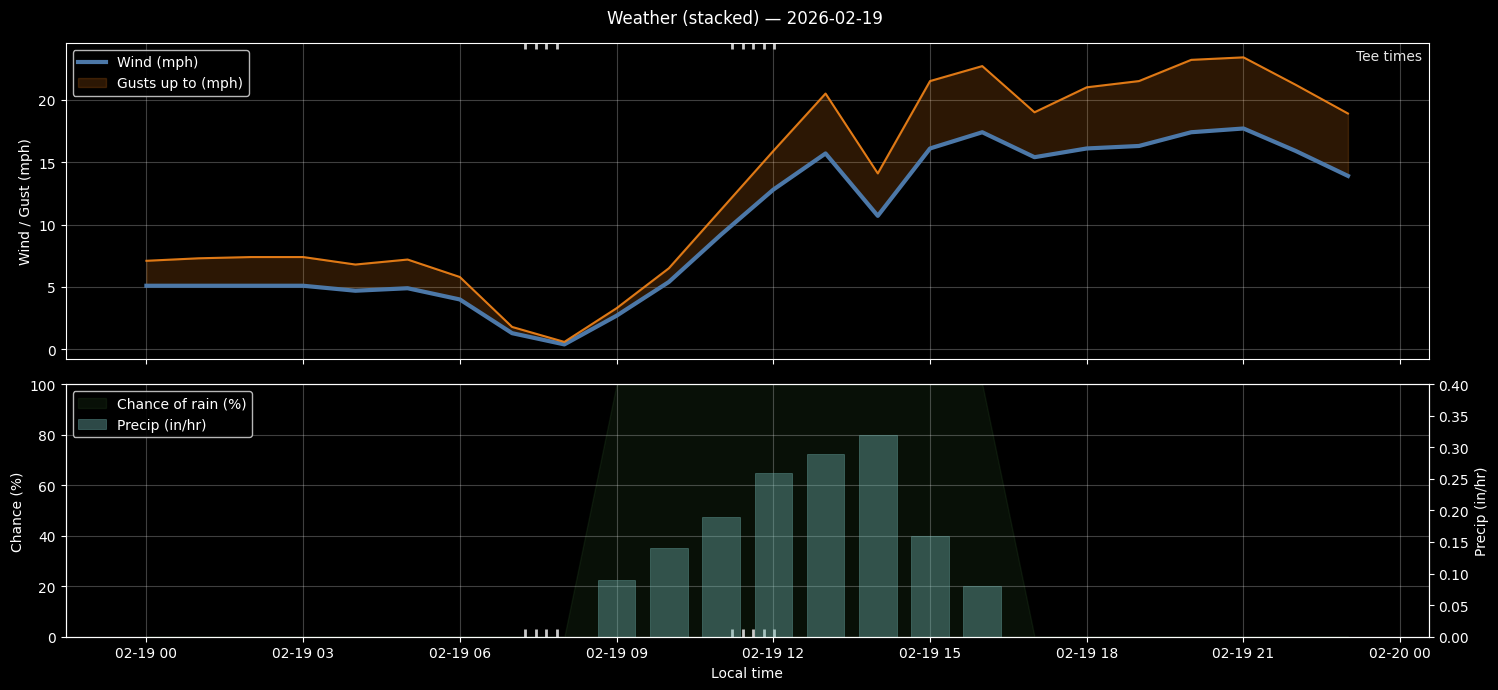

,tee_time_pst,group
0,2026-02-19 07:15:00,Valimaki / Poston / Hoey
1,2026-02-19 07:27:00,Kitayama / Echavarria / Knapp
2,2026-02-19 07:39:00,McCarty / Vegas / Pendrith
3,2026-02-19 07:51:00,Hoge / Cauley / Schmid
4,2026-02-19 11:13:00,Straka / Hall / Cantlay
5,2026-02-19 11:25:00,Gotterup / Rose / MacIntyre
6,2026-02-19 11:37:00,Scheffler / Schauffele / Si Woo Kim
7,2026-02-19 11:49:00,Min Woo Lee / Spieth / Berger
8,2026-02-19 12:01:00,Campbell / Clark / Penge


In [22]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_day_two_panel_with_rug(dfp, day, tee_times=None, tee_labels=None):
    d = dfp.copy()
    d["dt_local"] = pd.to_datetime(d["dt_local"], errors="coerce")
    d = d.dropna(subset=["dt_local"]).sort_values("dt_local")

    day_date = pd.to_datetime(day).date()
    d = d[d["dt_local"].dt.date == day_date].copy()
    if d.empty:
        raise ValueError(f"No data for {day}")

    for c in ["wind_mph", "gust_mph", "chance_of_rain", "precip_in"]:
        d[c] = pd.to_numeric(d[c], errors="coerce")

    x = d["dt_local"]
    wind = d["wind_mph"]
    gust = d["gust_mph"]
    rain = d["chance_of_rain"].clip(0, 100)
    precip = d["precip_in"].clip(lower=0)

    # Parse tee times
    tees = None
    if tee_times is not None:
        tees = [pd.to_datetime(t) for t in tee_times]

    c_wind = "#4C78A8"
    c_gust = "#F58518"
    c_rain = "#54A24B"
    c_prec = "#72B7B2"
    c_rug  = "#E0E0E0"  # light neutral so it pops on dark bg

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 7), sharex=True,
        gridspec_kw={"height_ratios": [2, 1.6]}
    )

    # Panel 1: wind/gust
    ax1.plot(x, wind, color=c_wind, linewidth=3.0, label="Wind (mph)", zorder=5)
    ax1.fill_between(x, wind, gust, where=(gust >= wind), interpolate=True,
                     color=c_gust, alpha=0.18, label="Gusts up to (mph)", zorder=4)
    ax1.plot(x, gust, color=c_gust, linewidth=1.5, alpha=0.9, zorder=6)
    ax1.set_ylabel("Wind / Gust (mph)")
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="upper left", framealpha=0.9)

    # Panel 2: rain + precip
    ax2.fill_between(x, 0, rain, color=c_rain, alpha=0.10, label="Chance of rain (%)", zorder=1)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("Chance (%)")
    ax2.grid(True, alpha=0.25)

    ax2p = ax2.twinx()
    ax2p.bar(x, precip, width=0.03, color=c_rug, alpha=0.0)  # no-op to keep axes stable if needed
    ax2p.bar(x, precip, width=0.03, color=c_prec, alpha=0.40,
             edgecolor=c_prec, linewidth=0.6, label="Precip (in/hr)", zorder=2)
    pmax = float(precip.max()) if precip.notna().any() else 0.0
    ax2p.set_ylim(0, max(0.05, pmax * 1.25))
    ax2p.set_ylabel("Precip (in/hr)")

    h2, l2 = ax2.get_legend_handles_labels()
    h2p, l2p = ax2p.get_legend_handles_labels()
    ax2.legend(h2 + h2p, l2 + l2p, loc="upper left", framealpha=0.9)

    # Tee-time rug ticks (small, unobtrusive)
    if tees is not None:
        ax1.vlines(tees, ymin=0.98, ymax=1.00, transform=ax1.get_xaxis_transform(),
                   color=c_rug, linewidth=2.0, alpha=0.9)
        ax2.vlines(tees, ymin=0.00, ymax=0.03, transform=ax2.get_xaxis_transform(),
                   color=c_rug, linewidth=2.0, alpha=0.9)

        # Small label to explain what the ticks are
        ax1.text(0.995, 0.98, "Tee times", transform=ax1.transAxes,
                 ha="right", va="top", fontsize=10, alpha=0.9)

    fig.suptitle(f"Weather (stacked) — {day}", y=0.98)
    ax2.set_xlabel("Local time")
    plt.tight_layout()
    plt.show()

    # Optional: print a clean tee-time table beneath (this is where names belong)
    if tee_times is not None and tee_labels is not None:
        tee_df = pd.DataFrame({"tee_time_pst": pd.to_datetime(tee_times), "group": tee_labels})
        tee_df = tee_df.sort_values("tee_time_pst")
        return tee_df

# Usage:
tee_df = plot_day_two_panel_with_rug(dfp, "2026-02-19", tee_times=tee_times, tee_labels=tee_labels)
tee_df


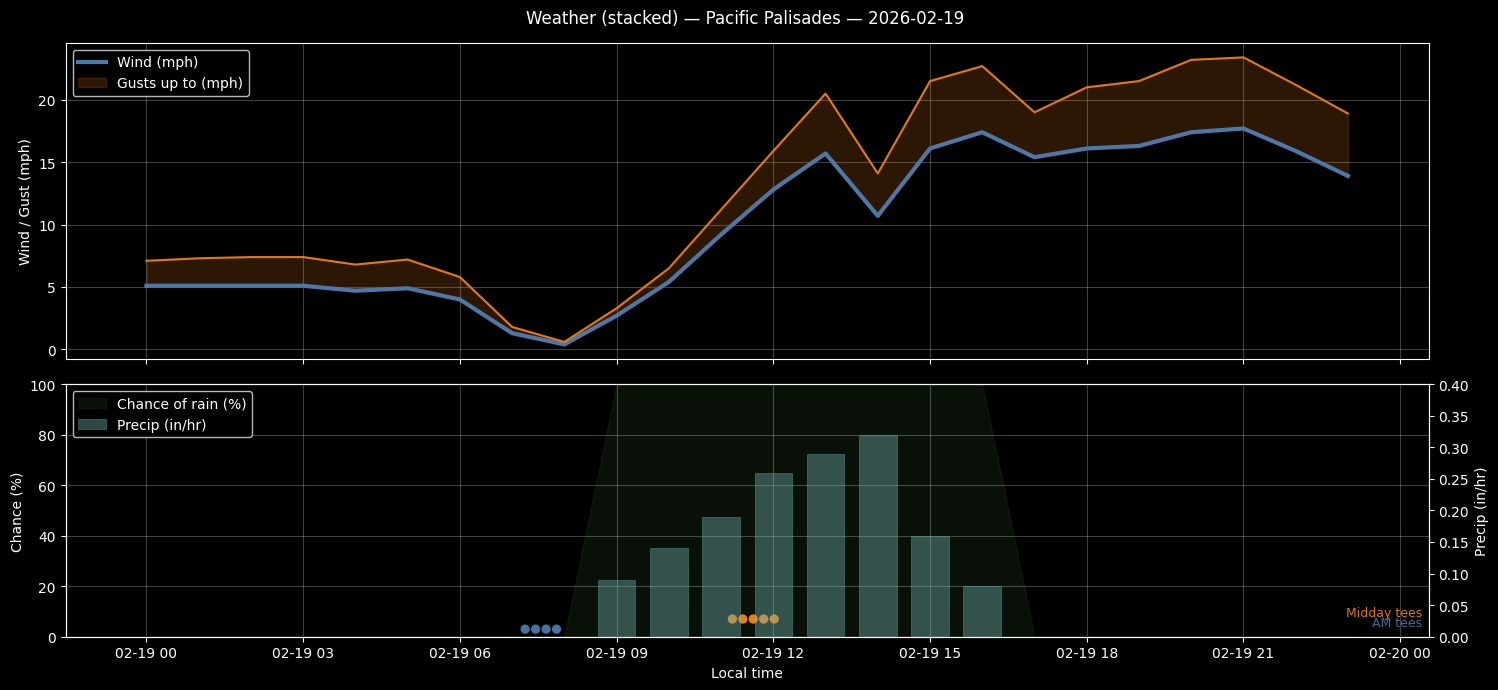

,tee_time_pst,group
0,2026-02-19 07:15:00,Valimaki / Poston / Hoey
1,2026-02-19 07:27:00,Kitayama / Echavarria / Knapp
2,2026-02-19 07:39:00,McCarty / Vegas / Pendrith
3,2026-02-19 07:51:00,Hoge / Cauley / Schmid
4,2026-02-19 11:13:00,Straka / Hall / Cantlay
5,2026-02-19 11:25:00,Gotterup / Rose / MacIntyre
6,2026-02-19 11:37:00,Scheffler / Schauffele / Si Woo Kim
7,2026-02-19 11:49:00,Min Woo Lee / Spieth / Berger
8,2026-02-19 12:01:00,Campbell / Clark / Penge


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# 1) Hardcoded tee times (EST -> PST already converted, Feb = -3h)
# ============================================================
tee_times = [
    "2026-02-19 07:15",  # 10:15 AM EST
    "2026-02-19 07:27",  # 10:27 AM EST
    "2026-02-19 07:39",  # 10:39 AM EST
    "2026-02-19 07:51",  # 10:51 AM EST
    "2026-02-19 11:13",  # 2:13 PM EST
    "2026-02-19 11:25",  # 2:25 PM EST
    "2026-02-19 11:37",  # 2:37 PM EST
    "2026-02-19 11:49",  # 2:49 PM EST
    "2026-02-19 12:01",  # 3:01 PM EST
]

tee_labels = [
    "Valimaki / Poston / Hoey",
    "Kitayama / Echavarria / Knapp",
    "McCarty / Vegas / Pendrith",
    "Hoge / Cauley / Schmid",
    "Straka / Hall / Cantlay",
    "Gotterup / Rose / MacIntyre",
    "Scheffler / Schauffele / Si Woo Kim",
    "Min Woo Lee / Spieth / Berger",
    "Campbell / Clark / Penge",
]

# Split into two colored lanes (based on your list order)
am_times   = tee_times[:4]   # 7:15–7:51 PST
mid_times  = tee_times[4:]   # 11:13–12:01 PST

# ============================================================
# 2) Helper: plot stacked weather + tee-time dot lanes
# ============================================================
def plot_day_weather_stacked_with_tee_dots(
    dfp: pd.DataFrame,
    day: str,
    *,
    am_tee_times=None,
    mid_tee_times=None,
    show_tee_table=True
):
    d = dfp.copy()
    d["dt_local"] = pd.to_datetime(d["dt_local"], errors="coerce")
    d = d.dropna(subset=["dt_local"]).sort_values("dt_local")

    day_date = pd.to_datetime(day).date()
    d = d[d["dt_local"].dt.date == day_date].copy()
    if d.empty:
        raise ValueError(f"No data for {day}. Available days: {sorted(dfp['dt_local'].dt.date.unique())}")

    # Required numeric cols
    for c in ["wind_mph", "gust_mph", "chance_of_rain", "precip_in"]:
        if c not in d.columns:
            raise KeyError(f"Missing '{c}' in dfp. Available: {list(d.columns)}")
        d[c] = pd.to_numeric(d[c], errors="coerce")

    x = d["dt_local"]
    wind = d["wind_mph"]
    gust = d["gust_mph"]
    rain = d["chance_of_rain"].clip(0, 100)
    precip = d["precip_in"].clip(lower=0)

    # Colors (distinct + readable on dark)
    c_wind = "#4C78A8"   # blue
    c_gust = "#F58518"   # orange
    c_rain = "#54A24B"   # green
    c_prec = "#72B7B2"   # teal

    c_am   = "#4C78A8"   # match wind
    c_mid  = "#F58518"   # match gust

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(15, 7), sharex=True,
        gridspec_kw={"height_ratios": [2, 1.6]}
    )

    # -------------------------
    # Panel 1: Wind + gust band
    # -------------------------
    ax1.plot(x, wind, color=c_wind, linewidth=3.0, label="Wind (mph)", zorder=5)
    ax1.fill_between(
        x, wind, gust,
        where=(gust >= wind),
        interpolate=True,
        color=c_gust,
        alpha=0.18,
        label="Gusts up to (mph)",
        zorder=4
    )
    ax1.plot(x, gust, color=c_gust, linewidth=1.5, alpha=0.9, zorder=6)
    ax1.set_ylabel("Wind / Gust (mph)")
    ax1.grid(True, alpha=0.25)
    ax1.legend(loc="upper left", framealpha=0.9)

    # -------------------------
    # Panel 2: Chance (%) + precip (in/hr)
    # -------------------------
    ax2.fill_between(x, 0, rain, color=c_rain, alpha=0.10, label="Chance of rain (%)", zorder=1)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("Chance (%)")
    ax2.grid(True, alpha=0.25)

    ax2p = ax2.twinx()
    ax2p.bar(
        x, precip,
        width=0.03,                 # hourly timestamps
        color=c_prec,
        alpha=0.40,
        edgecolor=c_prec,
        linewidth=0.6,
        label="Precip (in/hr)",
        zorder=2
    )
    pmax = float(precip.max()) if precip.notna().any() else 0.0
    ax2p.set_ylim(0, max(0.05, pmax * 1.25))
    ax2p.set_ylabel("Precip (in/hr)")

    # Combined legend for bottom panel
    h2, l2 = ax2.get_legend_handles_labels()
    h2p, l2p = ax2p.get_legend_handles_labels()
    ax2.legend(h2 + h2p, l2 + l2p, loc="upper left", framealpha=0.9)

    # -------------------------
    # Tee-time dots lane (clean)
    # -------------------------
    def _add_tee_dots_lane(ax, times, *, color, y, size=45, alpha=0.95):
        if not times:
            return
        tees = [pd.to_datetime(t) for t in times]
        ax.scatter(
            tees,
            [y] * len(tees),
            transform=ax.get_xaxis_transform(),
            s=size,
            alpha=alpha,
            color=color,
            edgecolors="none",
            zorder=30,
            clip_on=False,
        )

    # Put dots on bottom panel only (cleanest)
    _add_tee_dots_lane(ax2, am_tee_times,  color=c_am,  y=0.03)
    _add_tee_dots_lane(ax2, mid_tee_times, color=c_mid, y=0.07)

    # Tiny lane labels (no wave blocks)
    if am_tee_times:
        ax2.text(0.995, 0.03, "AM tees", transform=ax2.transAxes,
                 ha="right", va="bottom", fontsize=9, alpha=0.9, color=c_am)
    if mid_tee_times:
        ax2.text(0.995, 0.07, "Midday tees", transform=ax2.transAxes,
                 ha="right", va="bottom", fontsize=9, alpha=0.9, color=c_mid)

    # -------------------------
    # Title + layout
    # -------------------------
    title_loc = ""
    if "name" in d.columns and d["name"].notna().any():
        title_loc = f" — {d['name'].dropna().iloc[0]}"
    fig.suptitle(f"Weather (stacked){title_loc} — {day}", y=0.98)
    ax2.set_xlabel("Local time")

    plt.tight_layout()
    plt.show()

    # Optional: tee table (where identity belongs)
    if show_tee_table and (am_tee_times or mid_tee_times):
        all_times = (am_tee_times or []) + (mid_tee_times or [])
        # If the user passed a full tee list and labels, show them; otherwise just times
        return pd.DataFrame({"tee_time_local": pd.to_datetime(all_times)}).sort_values("tee_time_local")

# ============================================================
# 3) Call it (assumes dfp exists = your df_hourly cleaned)
# ============================================================
# If you don't already have dfp, uncomment the next lines:
# dfp = df_hourly.copy()
# dfp["dt_local"] = pd.to_datetime(dfp["dt_local"], errors="coerce")

plot_day_weather_stacked_with_tee_dots(
    dfp,
    "2026-02-19",
    am_tee_times=am_times,
    mid_tee_times=mid_times,
    show_tee_table=False
)

# Optional: show tee table with names (recommended)
tee_table = pd.DataFrame(
    {"tee_time_pst": pd.to_datetime(tee_times), "group": tee_labels}
).sort_values("tee_time_pst")
tee_table


In [1]:
# --- One-cell: Genesis field L12 map (Ball Striking vs Short Game) with headshot dots ---

import numpy as np
import pandas as pd
import plotly.graph_objects as go
import base64
from pathlib import Path

FIELDS_XLSX = "/Users/joshmacbook/python_projects/OAD/Data/MST/Fields.xlsx"
ALL_PLAYERS_XLSX = "/Users/joshmacbook/python_projects/OAD/Data/MST/All_players.xlsx"
ROUNDS_CSV  = "/Users/joshmacbook/python_projects/OAD/Data/MST/combined_roundlevel_2024_present.csv"

EVENT_ID = 7
WINDOW = 12

USE_MEDIAN_QUADRANTS = False
IMAGE_SCALE = 0.035
MAX_IMAGES = 140
LABEL_TOP_N = 0
JITTER = 0.0


def load_event_field(fields_path: str, event_id: int) -> pd.DataFrame:
    xls = pd.ExcelFile(fields_path)
    best = None
    for sh in xls.sheet_names:
        df = pd.read_excel(fields_path, sheet_name=sh)
        cols = {c.lower(): c for c in df.columns}
        if "event_id" in cols and ("dg_id" in cols or "player_name" in cols):
            df2 = df.copy()
            df2["event_id"] = pd.to_numeric(df2[cols["event_id"]], errors="coerce")
            if "dg_id" in cols:
                df2["dg_id"] = pd.to_numeric(df2[cols["dg_id"]], errors="coerce")
            if "player_name" in cols:
                df2["player_name"] = df2[cols["player_name"]].astype(str)
            sub = df2[df2["event_id"] == int(event_id)].copy()
            if not sub.empty:
                best = sub
                break
    if best is None or best.empty:
        raise ValueError(f"Could not find event_id={event_id} in any Fields.xlsx sheet.")

    keep = [c for c in ["event_id", "dg_id", "player_name"] if c in best.columns]
    best = best[keep].drop_duplicates().copy()
    if "dg_id" not in best.columns:
        raise ValueError("Field table did not contain dg_id.")

    best = best.dropna(subset=["dg_id"]).copy()
    best["dg_id"] = pd.to_numeric(best["dg_id"], errors="coerce")
    best = best.dropna(subset=["dg_id"]).copy()
    best["dg_id"] = best["dg_id"].astype(int)

    if "player_name" not in best.columns:
        best["player_name"] = best["dg_id"].astype(str)
    return best


def pick_recency_sort(df: pd.DataFrame):
    for c in ["start_date", "date", "round_date", "event_date"]:
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")
            return ([c], [False])
    if "event_id" in df.columns and "round_num" in df.columns:
        df["event_id"] = pd.to_numeric(df["event_id"], errors="coerce")
        df["round_num"] = pd.to_numeric(df["round_num"], errors="coerce")
        return (["event_id", "round_num"], [False, False])
    raise ValueError("Need start_date/date/round_date/event_date OR (event_id and round_num).")


def path_to_data_uri(path: str) -> str:
    p = Path(path)
    if not p.exists():
        return ""
    ext = p.suffix.lower().lstrip(".")
    mime = "image/png" if ext == "png" else "image/jpeg"
    enc = base64.b64encode(p.read_bytes()).decode("utf-8")
    return f"data:{mime};base64,{enc}"


def make_plot_with_headshots(d: pd.DataFrame, x: str, y: str, img_col: str) -> go.Figure:
    fig = go.Figure()

    # Keep ALL plotly tokens literal (no f-strings around %{...})
    hover = (
        "<b>%{customdata[0]}</b><br>"
        "Ball Striking (OTT+APP): %{x:.3f}<br>"
        "Short Game (ARG+PUTT): %{y:.3f}<br>"
        "APP: %{customdata[1]:.3f}<br>"
        "OTT: %{customdata[2]:.3f}<br>"
        "ARG: %{customdata[3]:.3f}<br>"
        "PUTT: %{customdata[4]:.3f}<br>"
        "Rounds L12: %{customdata[5]}<br>"
        "dg_id: %{customdata[6]}"
        "<extra></extra>"
    )

    fig.add_trace(
        go.Scatter(
            x=d[x],
            y=d[y],
            mode="markers",
            marker=dict(size=10, opacity=0.0),
            customdata=np.stack(
                [
                    d["player_name"].astype(str),
                    d[f"sg_app_L{WINDOW}"],
                    d[f"sg_ott_L{WINDOW}"],
                    d[f"sg_arg_L{WINDOW}"],
                    d[f"sg_putt_L{WINDOW}"],
                    d[f"rounds_L{WINDOW}"].fillna(0).astype(int),
                    d["dg_id"].astype(int),
                ],
                axis=1,
            ),
            hovertemplate=hover,
            showlegend=False,
        )
    )

    if LABEL_TOP_N and LABEL_TOP_N > 0:
        top = d.sort_values(x, ascending=False).head(int(LABEL_TOP_N)).copy()
        fig.add_trace(
            go.Scatter(
                x=top[x],
                y=top[y],
                mode="text",
                text=top["player_name"],
                textposition="top center",
                showlegend=False,
                hoverinfo="skip",
            )
        )

    if USE_MEDIAN_QUADRANTS:
        x0 = float(d[x].median())
        y0 = float(d[y].median())
    else:
        x0, y0 = 0.0, 0.0

    fig.add_shape(type="line", x0=x0, x1=x0, y0=float(d[y].min()), y1=float(d[y].max()))
    fig.add_shape(type="line", x0=float(d[x].min()), x1=float(d[x].max()), y0=y0, y1=y0)

    xrange = float(d[x].max() - d[x].min()) if len(d) else 1.0
    yrange = float(d[y].max() - d[y].min()) if len(d) else 1.0
    sizex = xrange * IMAGE_SCALE
    sizey = yrange * IMAGE_SCALE

    d_img = d.dropna(subset=[img_col]).copy()
    d_img[img_col] = d_img[img_col].astype(str).str.strip()
    d_img = d_img[d_img[img_col].str.len() > 3].copy()
    if len(d_img) > MAX_IMAGES:
        d_img = d_img.head(MAX_IMAGES).copy()

    for _, r in d_img.iterrows():
        src = str(r[img_col]).strip()
        if not src:
            continue
        fig.add_layout_image(
            dict(
                source=src,
                xref="x",
                yref="y",
                x=float(r[x]),
                y=float(r[y]),
                xanchor="center",
                yanchor="middle",
                sizex=sizex,
                sizey=sizey,
                sizing="contain",
                opacity=1.0,
                layer="above",
            )
        )

    fig.update_layout(
        title=f"Genesis Invitational Field — Ball Striking vs Short Game (L{WINDOW}) with Headshots",
        xaxis_title=f"Ball Striking = SG OTT + SG APP (L{WINDOW})",
        yaxis_title=f"Short Game = SG ARG + SG PUTT (L{WINDOW})",
        height=780,
        margin=dict(l=45, r=45, t=80, b=45),
    )
    return fig


# ---- build data ----
field = load_event_field(FIELDS_XLSX, EVENT_ID)

rounds = pd.read_csv(ROUNDS_CSV)
rounds["dg_id"] = pd.to_numeric(rounds["dg_id"], errors="coerce")
rounds = rounds.dropna(subset=["dg_id"]).copy()
rounds["dg_id"] = rounds["dg_id"].astype(int)

needed_stats = ["sg_putt", "sg_app", "sg_ott", "sg_arg"]
missing = [s for s in needed_stats if s not in rounds.columns]
if missing:
    raise ValueError(f"Rounds file missing required columns: {missing}")

sort_cols, ascending = pick_recency_sort(rounds)
rounds = rounds.sort_values(["dg_id"] + sort_cols, ascending=[True] + ascending)

tmp = rounds.groupby("dg_id", sort=False).head(WINDOW)

rolling = (
    tmp.groupby("dg_id", sort=False)[needed_stats]
    .mean()
    .add_suffix(f"_L{WINDOW}")
    .reset_index()
)
rolling[f"rounds_L{WINDOW}"] = tmp.groupby("dg_id", sort=False).size().values

ap = pd.read_excel(ALL_PLAYERS_XLSX)
ap_cols = {c.lower(): c for c in ap.columns}
ap = ap.rename(columns={ap_cols["dg_id"]: "dg_id", ap_cols["image"]: "image"}).copy()
ap["dg_id"] = pd.to_numeric(ap["dg_id"], errors="coerce")
ap = ap.dropna(subset=["dg_id"]).copy()
ap["dg_id"] = ap["dg_id"].astype(int)
ap["image"] = ap["image"].astype(str)

df = (
    field.merge(rolling, on="dg_id", how="left")
         .merge(ap[["dg_id", "image"]], on="dg_id", how="left")
)

df["ball_striking_L12"] = df[f"sg_ott_L{WINDOW}"] + df[f"sg_app_L{WINDOW}"]
df["short_game_L12"]    = df[f"sg_arg_L{WINDOW}"] + df[f"sg_putt_L{WINDOW}"]
df = df.dropna(subset=["ball_striking_L12", "short_game_L12"]).copy()

if JITTER and JITTER > 0:
    rng = np.random.default_rng(7)
    df["ball_striking_L12"] = df["ball_striking_L12"] + rng.normal(0, JITTER, size=len(df))
    df["short_game_L12"] = df["short_game_L12"] + rng.normal(0, JITTER, size=len(df))

df["image_src"] = df["image"].astype(str).str.strip()
mask_local = (df["image_src"].str.len() > 3) & (~df["image_src"].str.lower().str.startswith("http"))
if mask_local.any():
    df.loc[mask_local, "image_src"] = df.loc[mask_local, "image_src"].apply(path_to_data_uri)

fig = make_plot_with_headshots(df, x="ball_striking_L12", y="short_game_L12", img_col="image_src")
fig.show()


In [7]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pathlib import Path

# ----------------------------
# Paths / Params
# ----------------------------
ROUNDS_PATH = Path("/Users/joshmacbook/python_projects/OAD/Data/in Use/combined_rounds_all_2017_2026.csv")
OUT_DIR     = Path("/Users/joshmacbook/python_projects/OAD/Data/MST")
OUT_DIR.mkdir(parents=True, exist_ok=True)

COURSE_NUM = 500                 # Riviera
WINDOW_ROUNDS = 40               # pre-event skill window
MIN_PRIOR_ROUNDS = 20            # drop player-event if fewer prior rounds than this
MIN_EVENT_ROUNDS = 2             # require at least this many rounds in the event for outcome
SHRINK_K = 800                   # shrink course betas toward global mean (tune later)

WEIGHTS_PARQUET = OUT_DIR / "course_fit_weights_predictive_2017_2026.parquet"
WEIGHTS_CSV     = OUT_DIR / "course_fit_weights_predictive_2017_2026.csv"

RIV_FIT_PARQUET = OUT_DIR / f"course_{COURSE_NUM}_player_fit_L{WINDOW_ROUNDS}.parquet"
RIV_FIT_CSV     = OUT_DIR / f"course_{COURSE_NUM}_player_fit_L{WINDOW_ROUNDS}.csv"

# ----------------------------
# Load (only needed cols)
# ----------------------------
needed = {
    "tour","year","event_id","event_name","course_num","course_name",
    "dg_id","player_name","round_num","round_date",
    "sg_total","sg_ott","sg_app","sg_arg","sg_putt",
}
df = pd.read_csv(ROUNDS_PATH, usecols=lambda c: c in needed, low_memory=False)

# numeric cleanup
for c in ["year","event_id","course_num","dg_id","round_num","sg_total","sg_ott","sg_app","sg_arg","sg_putt"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["tour","year","event_id","course_num","dg_id","round_num","sg_total"]).copy()
df["tour"] = df["tour"].astype(str)
df["dg_id"] = df["dg_id"].astype(int)
df["event_id"] = df["event_id"].astype(int)
df["year"] = df["year"].astype(int)
df["course_num"] = df["course_num"].astype(int)
df["round_num"] = df["round_num"].astype(int)

# ----------------------------
# Sanity check: is event_id time-ordered when round_date exists?
# ----------------------------
if "round_date" in df.columns:
    tmp = df.dropna(subset=["round_date"]).copy()
    if len(tmp) > 0:
        tmp["round_date"] = pd.to_datetime(tmp["round_date"], errors="coerce")
        tmp = tmp.dropna(subset=["round_date"])
        if len(tmp) > 0:
            # per tour/year/event: earliest date
            chk = (
                tmp.groupby(["tour","year","event_id"], as_index=False)["round_date"]
                .min()
                .sort_values(["tour","year","round_date"])
            )
            # within each tour/year: does event_id increase with date?
            chk["event_id_diff"] = chk.groupby(["tour","year"])["event_id"].diff()
            bad = chk[(chk["event_id_diff"] < 0)].head(20)
            print("Sanity check (event_id monotonic vs available round_date):")
            if len(bad) == 0:
                print("  OK: no violations found (for rows where round_date exists).")
            else:
                print("  WARNING: found event_id order violations (sample below).")
                display(bad[["tour","year","event_id","round_date","event_id_diff"]])

# ----------------------------
# Define event ordering WITHOUT dates:
# earlier means (tour, year, event_id) lexicographically
# ----------------------------
# "event_key" identifies a single tournament instance (tour+year+event)
df["event_key"] = (
    df["tour"].astype(str)
    + "|" + df["year"].astype(str)
    + "|" + df["event_id"].astype(str)
)

# order key for comparisons
# (tour, year, event_id) -> sortable tuple; we store as columns for merge logic
order_cols = ["tour","year","event_id"]

# ----------------------------
# Focus: course_num = 500 (Riviera)
# ----------------------------
riv = df[df["course_num"] == COURSE_NUM].copy()
if riv.empty:
    raise ValueError(f"No rows found for course_num={COURSE_NUM}")

# identify Riviera events (tour/year/event_id)
riv_events = riv[order_cols + ["event_key","event_name","course_name"]].drop_duplicates().copy()
riv_events = riv_events.sort_values(order_cols).reset_index(drop=True)

print(f"Riviera events found: {len(riv_events)}")
display(riv_events.tail(10))

# ----------------------------
# Build player-event dataset:
# outcome = event sum(sg_total)
# predictors = pre-event rolling means of sg_ott/app/arg/putt over last WINDOW_ROUNDS rounds
# using all tours? -> we’ll use same TOUR history to stay honest.
# ----------------------------
skill_cols = ["sg_ott","sg_app","sg_arg","sg_putt"]

# ensure skills are numeric; some tours/events may have missing split SG
for c in skill_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# We’ll build a per-player timeline per TOUR using (year,event_id,round_num).
# This avoids needing round_date.
df = df.sort_values(["tour","dg_id","year","event_id","round_num"]).copy()

# Precompute cumulative index per player-tour to allow quick "last N rounds before event"
df["pt_round_idx"] = df.groupby(["tour","dg_id"]).cumcount()

# helper map: for each event_key, the max pt_round_idx included in that event for each player
# (we’ll use it to take history strictly before first round of the event)
event_first_idx = (
    df.groupby(["tour","year","event_id","dg_id"], as_index=False)["pt_round_idx"]
    .min()
    .rename(columns={"pt_round_idx":"event_first_pt_idx"})
)

# event outcome (sum sg_total within event) + n rounds in event
event_outcome = (
    df.groupby(["tour","year","event_id","course_num","dg_id"], as_index=False)
      .agg(event_sg_total=("sg_total","sum"),
           event_rounds=("sg_total","size"))
)

# merge first idx
event_outcome = event_outcome.merge(
    event_first_idx, on=["tour","year","event_id","dg_id"], how="left"
)

# keep only Riviera events
event_outcome = event_outcome[event_outcome["course_num"] == COURSE_NUM].copy()

# compute rolling skills before event:
# for each player-event, take the WINDOW_ROUNDS rows with pt_round_idx < event_first_pt_idx
# and average available skill cols (require at least MIN_PRIOR_ROUNDS non-null in sg_total history)
rows = []
for r in event_outcome.itertuples(index=False):
    tour, year, event_id, course_num, dg_id, y, erounds, first_idx = (
        r.tour, r.year, r.event_id, r.course_num, r.dg_id, r.event_sg_total, r.event_rounds, r.event_first_pt_idx
    )

    if pd.isna(first_idx):
        continue

    hist = df[(df["tour"] == tour) & (df["dg_id"] == dg_id) & (df["pt_round_idx"] < first_idx)].tail(WINDOW_ROUNDS)

    # require enough prior rounds (based on sg_total count)
    if hist["sg_total"].notna().sum() < MIN_PRIOR_ROUNDS:
        continue

    # compute mean skills; if a skill col is missing a lot, it will be NaN -> we’ll drop later
    feats = {f"{c}_pre": float(hist[c].mean()) if c in hist.columns else np.nan for c in skill_cols}
    feats.update({
        "tour": tour, "year": int(year), "event_id": int(event_id), "course_num": int(course_num),
        "dg_id": int(dg_id),
        "event_sg_total": float(y),
        "event_rounds": int(erounds),
        "prior_rounds_used": int(hist.shape[0]),
    })
    rows.append(feats)

pe = pd.DataFrame(rows)

# join names for convenience
names = df[["tour","dg_id","player_name"]].drop_duplicates()
pe = pe.merge(names, on=["tour","dg_id"], how="left")

# require event has enough rounds (avoid WD/partial) and require all 4 skills available
pe = pe[pe["event_rounds"] >= MIN_EVENT_ROUNDS].copy()

need_pre = [f"{c}_pre" for c in skill_cols]
pe = pe.dropna(subset=need_pre + ["event_sg_total"]).copy()

print(f"\nPlayer-event rows for Riviera regression: {len(pe)}")
display(pe.head())

# ----------------------------
# Standardize the *pre-event* skills (global within this course sample)
# ----------------------------
mu = pe[need_pre].mean()
sd = pe[need_pre].std(ddof=0).replace(0, np.nan)

for c in need_pre:
    pe[f"z_{c}"] = (pe[c] - mu[c]) / sd[c]

zcols = [f"z_{c}" for c in need_pre]
pe = pe.dropna(subset=zcols).copy()

# ----------------------------
# Regression: event_sg_total ~ z_skills
# ----------------------------
X = sm.add_constant(pe[zcols])
y = pe["event_sg_total"]
m = sm.OLS(y, X).fit()

params = m.params.to_dict()
r2 = float(m.rsquared)

beta_ott  = float(params.get("z_sg_ott_pre", np.nan))
beta_app  = float(params.get("z_sg_app_pre", np.nan))
beta_arg  = float(params.get("z_sg_arg_pre", np.nan))
beta_putt = float(params.get("z_sg_putt_pre", np.nan))

out = pd.DataFrame([{
    "course_num": COURSE_NUM,
    "tour_scope": "same-tour-history",
    "n_player_events": int(len(pe)),
    "r2": r2,
    "beta_ott": beta_ott,
    "beta_app": beta_app,
    "beta_arg": beta_arg,
    "beta_putt": beta_putt,
}])

# ----------------------------
# Shrink betas toward "average course" (here: just shrink toward zeros for now)
# You can later replace 0s with global means once you expand to all courses.
# ----------------------------
w = out["n_player_events"] / (out["n_player_events"] + SHRINK_K)
out["beta_ott_shrunk"]  = w * out["beta_ott"]
out["beta_app_shrunk"]  = w * out["beta_app"]
out["beta_arg_shrunk"]  = w * out["beta_arg"]
out["beta_putt_shrunk"] = w * out["beta_putt"]

out["predictability"] = np.sqrt(
    out["beta_ott_shrunk"]**2 + out["beta_app_shrunk"]**2 + out["beta_arg_shrunk"]**2 + out["beta_putt_shrunk"]**2
)

abs_sum = (
    out[["beta_ott_shrunk","beta_app_shrunk","beta_arg_shrunk","beta_putt_shrunk"]]
    .abs()
    .sum(axis=1)
    .replace(0, np.nan)
)
out["imp_ott"]  = out["beta_ott_shrunk"].abs()  / abs_sum
out["imp_app"]  = out["beta_app_shrunk"].abs()  / abs_sum
out["imp_arg"]  = out["beta_arg_shrunk"].abs()  / abs_sum
out["imp_putt"] = out["beta_putt_shrunk"].abs() / abs_sum

# write "weights" (single-course version)
out.to_parquet(WEIGHTS_PARQUET, index=False)
out.to_csv(WEIGHTS_CSV, index=False)

print("\nRiviera predictive course-fit weights:")
display(out)

# ----------------------------
# Player fit table for Riviera (using *latest available* pre-event z-skills)
# This is what you’ll use weekly: score = betas dot z_skills
# ----------------------------
b_ott  = float(out.loc[0,"beta_ott_shrunk"])
b_app  = float(out.loc[0,"beta_app_shrunk"])
b_arg  = float(out.loc[0,"beta_arg_shrunk"])
b_putt = float(out.loc[0,"beta_putt_shrunk"])

# for each player, take their most recent pre-event skill observation in pe
latest = (
    pe.sort_values(["tour","dg_id","year","event_id"], ascending=[True, True, False, False])
      .groupby(["tour","dg_id"], as_index=False)
      .head(1)
      .copy()
)

latest["course_fit_score"] = (
    b_ott  * latest["z_sg_ott_pre"]
    + b_app  * latest["z_sg_app_pre"]
    + b_arg  * latest["z_sg_arg_pre"]
    + b_putt * latest["z_sg_putt_pre"]
)

cols_show = ["tour","dg_id","player_name","course_fit_score","z_sg_ott_pre","z_sg_app_pre","z_sg_arg_pre","z_sg_putt_pre"]
latest = latest.sort_values("course_fit_score", ascending=False)[cols_show].reset_index(drop=True)

latest.to_parquet(RIV_FIT_PARQUET, index=False)
latest.to_csv(RIV_FIT_CSV, index=False)

print(f"\nWrote Riviera player fit table:\n- {RIV_FIT_PARQUET}\n- {RIV_FIT_CSV}")
display(latest.head(30))


Sanity check (event_id monotonic vs available round_date):


,tour,year,event_id,round_date,event_id_diff
4,EURO,2022,2022108,2022-03-03,-40.0
3,EURO,2022,2022106,2022-03-24,-41.0
5,EURO,2022,2022114,2022-05-05,-37.0
27,EURO,2022,2022145,2022-11-10,-11.0
26,EURO,2022,2022143,2022-11-17,-2.0
47,EURO,2023,2023117,2023-05-04,-4.0
67,EURO,2023,2023145,2023-11-09,-5.0
68,EURO,2023,2023146,2023-11-16,-567.0
82,EURO,2024,2024110,2024-02-22,-37.0
87,EURO,2024,2024116,2024-05-03,-1.0


Riviera events found: 8


,tour,year,event_id,event_key,event_name,course_name
0,PGA,2017,7,PGA|2017|7,Genesis Open,Riviera CC
1,PGA,2018,7,PGA|2018|7,Genesis Open,Riviera CC
2,PGA,2019,7,PGA|2019|7,Genesis Open,Riviera Country Club
3,PGA,2020,7,PGA|2020|7,The Genesis Invitational,Riviera Country Club
4,PGA,2021,7,PGA|2021|7,The Genesis Invitational,The Riviera Country Club
5,PGA,2022,7,PGA|2022|7,The Genesis Invitational,The Riviera Country Club
6,PGA,2023,7,PGA|2023|7,The Genesis Invitational,The Riviera Country Club
7,PGA,2024,7,PGA|2024|7,The Genesis Invitational,The Riviera Country Club



Player-event rows for Riviera regression: 841


,sg_ott_pre,sg_app_pre,sg_arg_pre,sg_putt_pre,tour,year,event_id,course_num,dg_id,event_sg_total,event_rounds,prior_rounds_used,player_name
0,0.057133,-0.192667,-0.293600,0.312800,PGA,2017,7,500,11330,11.497,4,20,"Brown, Scott"
1,0.126972,-0.193194,0.246306,-0.565778,PGA,2018,7,500,653,-5.675,4,40,"Singh, Vijay"
2,-0.534917,-0.329792,0.319000,0.391292,PGA,2018,7,500,874,-0.662,2,40,"Els, Ernie"
3,-0.142839,0.662581,0.205613,0.952581,PGA,2018,7,500,1547,10.325,4,40,"Mickelson, Phil"
4,0.064667,-0.556333,-0.100033,-0.298433,PGA,2018,7,500,1804,-3.662,2,40,"Choi, K.J."



Riviera predictive course-fit weights:


,course_num,tour_scope,n_player_events,r2,beta_ott,beta_app,beta_arg,beta_putt,beta_ott_shrunk,beta_app_shrunk,beta_arg_shrunk,beta_putt_shrunk,predictability,imp_ott,imp_app,imp_arg,imp_putt
0,500,same-tour-history,841,0.106542,1.10464,0.64142,0.568109,0.779245,0.56612,0.328723,0.291151,0.399357,0.820247,0.357094,0.20735,0.183651,0.251904



Wrote Riviera player fit table:
- /Users/joshmacbook/python_projects/OAD/Data/MST/course_500_player_fit_L40.parquet
- /Users/joshmacbook/python_projects/OAD/Data/MST/course_500_player_fit_L40.csv


,tour,dg_id,player_name,course_fit_score,z_sg_ott_pre,z_sg_app_pre,z_sg_arg_pre,z_sg_putt_pre
0,PGA,18417,"Scheffler, Scottie",2.112418,2.221361,2.835165,0.958017,-0.891559
1,PGA,19841,"DeChambeau, Bryson",1.963158,2.616468,-0.960498,0.024171,1.979744
2,PGA,10091,"McIlroy, Rory",1.898841,1.973196,0.953723,0.818892,0.575533
3,PGA,19895,"Schauffele, Xander",1.894499,0.990068,1.426541,0.624236,1.711044
4,PGA,19195,"Rahm, Jon",1.695200,2.069199,0.349134,0.204377,0.875190
5,PGA,12294,"Fleetwood, Tommy",1.626042,1.053507,0.567839,0.979057,1.397035
6,PGA,23950,"Aberg, Ludvig",1.525956,2.051897,0.152563,0.110720,0.706009
7,PGA,18841,"Hovland, Viktor",1.506602,1.747073,1.051384,0.235792,0.258627
8,PGA,6430,"Scott, Adam",1.250009,0.768510,1.110070,-0.330251,1.367667
9,PGA,19455,"Pereira, Mito",1.249715,0.578849,0.712439,0.897984,1.067647


In [8]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from pathlib import Path

# ============================================================
# Predictive Course Fit Weights (TEST SET)
# - Builds per-course predictive betas:
#     event_sg_total ~ pre-event rolling skill (OTT/APP/ARG/PUTT)
# - No round_date required; uses (tour, year, event_id, round_num) ordering
# - "same-tour-history": player skill history only from same tour
# - Saves a TEST weights file + relative comparisons within the test set
# ============================================================

ROUNDS_PATH = Path("/Users/joshmacbook/python_projects/OAD/Data/in Use/combined_rounds_all_2017_2026.csv")
OUT_DIR     = Path("/Users/joshmacbook/python_projects/OAD/Data/MST")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TEST_COURSES = [500, 928, 9, 11, 665]

WINDOW_ROUNDS = 40
MIN_PRIOR_ROUNDS = 20
MIN_EVENT_ROUNDS = 2
SHRINK_K = 800  # shrink betas toward 0 within each course (practical stabilizer for test)

OUT_PARQUET = OUT_DIR / "course_fit_weights_predictive_TEST.parquet"
OUT_CSV     = OUT_DIR / "course_fit_weights_predictive_TEST.csv"

# ----------------------------
# Load (only needed columns)
# ----------------------------
needed = {
    "tour","year","event_id","event_name","course_num","course_name",
    "dg_id","player_name","round_num","round_date",
    "sg_total","sg_ott","sg_app","sg_arg","sg_putt",
}
df = pd.read_csv(ROUNDS_PATH, usecols=lambda c: c in needed, low_memory=False)

# numeric cleanup
for c in ["year","event_id","course_num","dg_id","round_num","sg_total","sg_ott","sg_app","sg_arg","sg_putt"]:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

df = df.dropna(subset=["tour","year","event_id","course_num","dg_id","round_num","sg_total"]).copy()
df["tour"] = df["tour"].astype(str)
df["dg_id"] = df["dg_id"].astype(int)
df["event_id"] = df["event_id"].astype(int)
df["year"] = df["year"].astype(int)
df["course_num"] = df["course_num"].astype(int)
df["round_num"] = df["round_num"].astype(int)

# Optional sanity check: event_id ordering vs round_date where available
if "round_date" in df.columns:
    tmp = df.dropna(subset=["round_date"]).copy()
    if len(tmp) > 0:
        tmp["round_date"] = pd.to_datetime(tmp["round_date"], errors="coerce")
        tmp = tmp.dropna(subset=["round_date"])
        if len(tmp) > 0:
            chk = (
                tmp.groupby(["tour","year","event_id"], as_index=False)["round_date"]
                .min()
                .sort_values(["tour","year","round_date"])
            )
            chk["event_id_diff"] = chk.groupby(["tour","year"])["event_id"].diff()
            bad = chk[(chk["event_id_diff"] < 0)]
            print("Sanity check (event_id monotonic vs available round_date):",
                  "OK" if len(bad) == 0 else f"WARNING ({len(bad)} violations where round_date exists)")
            if len(bad) > 0:
                display(bad.head(10)[["tour","year","event_id","round_date","event_id_diff"]])

# Skills we need (require full splits in *history* and *event outcome* pipeline)
skill_cols = ["sg_ott","sg_app","sg_arg","sg_putt"]
for c in skill_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Sort to create a stable per-player-tour timeline (no dates required)
df = df.sort_values(["tour","dg_id","year","event_id","round_num"]).copy()
df["pt_round_idx"] = df.groupby(["tour","dg_id"]).cumcount()

# First index of each (tour,year,event,player) for lookback cutoff
event_first_idx = (
    df.groupby(["tour","year","event_id","dg_id"], as_index=False)["pt_round_idx"]
      .min()
      .rename(columns={"pt_round_idx":"event_first_pt_idx"})
)

# Event outcome table (player-event) with event_total and number of rounds
event_outcome = (
    df.groupby(["tour","year","event_id","course_num","dg_id"], as_index=False)
      .agg(event_sg_total=("sg_total","sum"),
           event_rounds=("sg_total","size"))
      .merge(event_first_idx, on=["tour","year","event_id","dg_id"], how="left")
)

# names for convenience
names = df[["tour","dg_id","player_name"]].drop_duplicates()

def fit_one_course(course_num: int) -> dict:
    eo = event_outcome[event_outcome["course_num"] == int(course_num)].copy()
    if eo.empty:
        return {
            "course_num": int(course_num),
            "status": "no rows for course",
        }

    rows = []
    for r in eo.itertuples(index=False):
        tour, year, event_id, cnum, dg_id, y, erounds, first_idx = (
            r.tour, r.year, r.event_id, r.course_num, r.dg_id, r.event_sg_total, r.event_rounds, r.event_first_pt_idx
        )
        if pd.isna(first_idx):
            continue
        if int(erounds) < MIN_EVENT_ROUNDS:
            continue

        # history strictly before event starts, same tour
        hist = df[(df["tour"] == tour) & (df["dg_id"] == dg_id) & (df["pt_round_idx"] < first_idx)].tail(WINDOW_ROUNDS)

        if hist["sg_total"].notna().sum() < MIN_PRIOR_ROUNDS:
            continue

        # require split SG in history (otherwise predictors are NaN)
        feats = {}
        ok = True
        for c in skill_cols:
            v = hist[c].mean()
            if pd.isna(v):
                ok = False
                break
            feats[f"{c}_pre"] = float(v)
        if not ok:
            continue

        feats.update({
            "tour": tour,
            "year": int(year),
            "event_id": int(event_id),
            "course_num": int(cnum),
            "dg_id": int(dg_id),
            "event_sg_total": float(y),
            "event_rounds": int(erounds),
            "prior_rounds_used": int(hist.shape[0]),
        })
        rows.append(feats)

    pe = pd.DataFrame(rows)
    if pe.empty or len(pe) < 150:
        # 150 is an arbitrary “don’t trust it” threshold; tune if needed
        return {
            "course_num": int(course_num),
            "status": f"insufficient player-event rows ({len(pe)})",
            "n_player_events": int(len(pe)),
        }

    pe = pe.merge(names, on=["tour","dg_id"], how="left")

    need_pre = [f"{c}_pre" for c in skill_cols]
    pe = pe.dropna(subset=need_pre + ["event_sg_total"]).copy()

    # standardize within this course sample (pre-event skills)
    mu = pe[need_pre].mean()
    sd = pe[need_pre].std(ddof=0).replace(0, np.nan)

    for c in need_pre:
        pe[f"z_{c}"] = (pe[c] - mu[c]) / sd[c]

    zcols = [f"z_{c}" for c in need_pre]
    pe = pe.dropna(subset=zcols).copy()

    X = sm.add_constant(pe[zcols])
    y = pe["event_sg_total"]

    m = sm.OLS(y, X).fit()

    beta_ott  = float(m.params.get("z_sg_ott_pre", np.nan))
    beta_app  = float(m.params.get("z_sg_app_pre", np.nan))
    beta_arg  = float(m.params.get("z_sg_arg_pre", np.nan))
    beta_putt = float(m.params.get("z_sg_putt_pre", np.nan))

    n = int(len(pe))
    w = n / (n + SHRINK_K)

    beta_ott_s  = w * beta_ott
    beta_app_s  = w * beta_app
    beta_arg_s  = w * beta_arg
    beta_putt_s = w * beta_putt

    pred = float(np.sqrt(beta_ott_s**2 + beta_app_s**2 + beta_arg_s**2 + beta_putt_s**2))
    abs_sum = abs(beta_ott_s) + abs(beta_app_s) + abs(beta_arg_s) + abs(beta_putt_s)
    if abs_sum == 0:
        imp_ott = imp_app = imp_arg = imp_putt = np.nan
    else:
        imp_ott  = abs(beta_ott_s)  / abs_sum
        imp_app  = abs(beta_app_s)  / abs_sum
        imp_arg  = abs(beta_arg_s)  / abs_sum
        imp_putt = abs(beta_putt_s) / abs_sum

    # course name (most common)
    cname = df.loc[df["course_num"] == int(course_num), "course_name"].dropna()
    cname = cname.mode().iloc[0] if len(cname) else None

    return {
        "course_num": int(course_num),
        "course_name": cname,
        "status": "ok",
        "n_player_events": n,
        "r2": float(m.rsquared),
        "beta_ott": beta_ott,
        "beta_app": beta_app,
        "beta_arg": beta_arg,
        "beta_putt": beta_putt,
        "beta_ott_shrunk": beta_ott_s,
        "beta_app_shrunk": beta_app_s,
        "beta_arg_shrunk": beta_arg_s,
        "beta_putt_shrunk": beta_putt_s,
        "predictability": pred,
        "imp_ott": imp_ott,
        "imp_app": imp_app,
        "imp_arg": imp_arg,
        "imp_putt": imp_putt,
    }

# ----------------------------
# Run test courses
# ----------------------------
results = [fit_one_course(c) for c in TEST_COURSES]
res = pd.DataFrame(results)

# Relative comparisons across this test set
# z-score the SHRUNK betas per attribute across courses (within test set)
for col in ["beta_ott_shrunk","beta_app_shrunk","beta_arg_shrunk","beta_putt_shrunk"]:
    if col in res.columns:
        m = res.loc[res["status"]=="ok", col].mean()
        s = res.loc[res["status"]=="ok", col].std(ddof=0)
        if pd.isna(s) or s == 0:
            res[f"{col}_z"] = np.nan
        else:
            res[f"{col}_z"] = (res[col] - m) / s

# "Relative importance view" (0..1) within each course using abs(shrunk betas)
abs_sum = (
    res[["beta_ott_shrunk","beta_app_shrunk","beta_arg_shrunk","beta_putt_shrunk"]]
    .abs()
    .sum(axis=1)
    .replace(0, np.nan)
)
res["rel_ott_0to1"]  = res["beta_ott_shrunk"].abs()  / abs_sum
res["rel_app_0to1"]  = res["beta_app_shrunk"].abs()  / abs_sum
res["rel_arg_0to1"]  = res["beta_arg_shrunk"].abs()  / abs_sum
res["rel_putt_0to1"] = res["beta_putt_shrunk"].abs() / abs_sum

# Save (OVERWRITE)
res.to_parquet(OUT_PARQUET, index=False)
res.to_csv(OUT_CSV, index=False)

print(f"OVERWROTE test weights:\n- {OUT_PARQUET}\n- {OUT_CSV}\n")
display(res)


Sanity check (event_id monotonic vs available round_date): WARNING (122 violations where round_date exists)


,tour,year,event_id,round_date,event_id_diff
4,EURO,2022,2022108,2022-03-03,-40.0
3,EURO,2022,2022106,2022-03-24,-41.0
5,EURO,2022,2022114,2022-05-05,-37.0
27,EURO,2022,2022145,2022-11-10,-11.0
26,EURO,2022,2022143,2022-11-17,-2.0
47,EURO,2023,2023117,2023-05-04,-4.0
67,EURO,2023,2023145,2023-11-09,-5.0
68,EURO,2023,2023146,2023-11-16,-567.0
82,EURO,2024,2024110,2024-02-22,-37.0
87,EURO,2024,2024116,2024-05-03,-1.0


OVERWROTE test weights:
- /Users/joshmacbook/python_projects/OAD/Data/MST/course_fit_weights_predictive_TEST.parquet
- /Users/joshmacbook/python_projects/OAD/Data/MST/course_fit_weights_predictive_TEST.csv



,course_num,course_name,status,n_player_events,r2,beta_ott,beta_app,beta_arg,beta_putt,beta_ott_shrunk,...,imp_arg,imp_putt,beta_ott_shrunk_z,beta_app_shrunk_z,beta_arg_shrunk_z,beta_putt_shrunk_z,rel_ott_0to1,rel_app_0to1,rel_arg_0to1,rel_putt_0to1
0,500,The Riviera Country Club,ok,841,0.106542,1.104640,0.641420,0.568109,0.779245,0.566120,...,0.183651,0.251904,0.201239,-0.714813,0.207308,0.854453,0.357094,0.207350,0.183651,0.251904
1,928,PGA National Resort (The Champion Course),ok,278,0.063841,0.662419,0.883825,0.470080,0.127991,0.170828,...,0.219222,0.059689,-1.763186,-1.524576,-1.488060,-1.898192,0.308919,0.412171,0.219222,0.059689
2,9,Bay Hill Club & Lodge,ok,864,0.118417,1.252356,1.013871,0.370120,0.575509,0.650262,...,0.115236,0.179183,0.619387,0.873497,-0.780168,0.099063,0.389917,0.315665,0.115236,0.179183
3,11,TPC Sawgrass,ok,1094,0.107476,1.323310,0.765984,0.659373,0.678144,0.764362,...,0.192416,0.197894,1.186412,0.198755,1.102376,0.796958,0.386164,0.223527,0.192416,0.197894
4,665,Innisbrook Resort (Copperhead),ok,1174,0.106413,0.801296,0.946620,0.616155,0.513337,0.476556,...,0.214135,0.178402,-0.243852,1.167137,0.958544,0.147719,0.278479,0.328984,0.214135,0.178402
